In [1]:
# %% [markdown]
# Case 01 – Initial exploration

# %%
import pandas as pd
import numpy as np

df = pd.read_csv("../data/billing.csv")
df.head()

,usage_date,billing_period,account_id,account_name,business_unit,environment,region,service_name,product_name,team,...,sla_tier,budget_amount,forecast_baseline_cost,acquisition_phase,tag_owner,tag_environment,tag_product,tag_cost_center,allocation_status,anomaly_flag
0,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,AWS Fargate,ai-assistant,ml-engineering,...,premium,98400.73,97716.41,pre-integration,ml-engineering,staging,ai-assistant,core-platform,allocated,0
1,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Fargate,workflow-intelligence,product-analytics,...,standard,271679.01,258624.24,pre-integration,product-analytics,dev,NaN,core-platform,allocated,0
2,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,prod,us-east-1,AWS Lambda,ai-assistant,data,...,enterprise,216109.16,199963.24,pre-integration,data,prod,ai-assistant,core-platform,allocated,0
3,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Lambda,workflow-intelligence,product-analytics,...,standard,194208.81,191883.15,pre-integration,product-analytics,dev,NaN,core-platform,partially-allocated,0
4,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,Amazon CloudWatch,reporting-api,ml-engineering,...,premium,101965.35,102659.37,pre-integration,ml-engineering,staging,reporting-api,core-platform,allocated,0


In [2]:
import plotly
print(plotly.__version__)

6.7.0


In [3]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

In [4]:
df

,usage_date,billing_period,account_id,account_name,business_unit,environment,region,service_name,product_name,team,...,sla_tier,budget_amount,forecast_baseline_cost,acquisition_phase,tag_owner,tag_environment,tag_product,tag_cost_center,allocation_status,anomaly_flag
0,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,AWS Fargate,ai-assistant,ml-engineering,...,premium,98400.73,97716.41,pre-integration,ml-engineering,staging,ai-assistant,core-platform,allocated,0
1,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Fargate,workflow-intelligence,product-analytics,...,standard,271679.01,258624.24,pre-integration,product-analytics,dev,NaN,core-platform,allocated,0
2,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,prod,us-east-1,AWS Lambda,ai-assistant,data,...,enterprise,216109.16,199963.24,pre-integration,data,prod,ai-assistant,core-platform,allocated,0
3,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Lambda,workflow-intelligence,product-analytics,...,standard,194208.81,191883.15,pre-integration,product-analytics,dev,NaN,core-platform,partially-allocated,0
4,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,Amazon CloudWatch,reporting-api,ml-engineering,...,premium,101965.35,102659.37,pre-integration,ml-engineering,staging,reporting-api,core-platform,allocated,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,Amazon RDS,reporting-api,product-analytics,...,standard,136186.09,142806.35,post-integration,product-analytics,prod,reporting-api,shared-ops,partially-allocated,0
4996,2026-01-28,2026-01,1003,shared-services,shared-ops,dev,us-east-1,Amazon RDS,workflow-intelligence,data,...,enterprise,205486.34,210626.57,post-integration,data,dev,workflow-intelligence,shared-ops,allocated,0
4997,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,Amazon RDS,ai-assistant,product-analytics,...,standard,129461.87,135340.90,post-integration,product-analytics,prod,ai-assistant,shared-ops,partially-allocated,0
4998,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,NAT Gateway,ai-assistant,platform,...,standard,115124.18,123360.32,post-integration,NaN,prod,ai-assistant,shared-ops,allocated,0


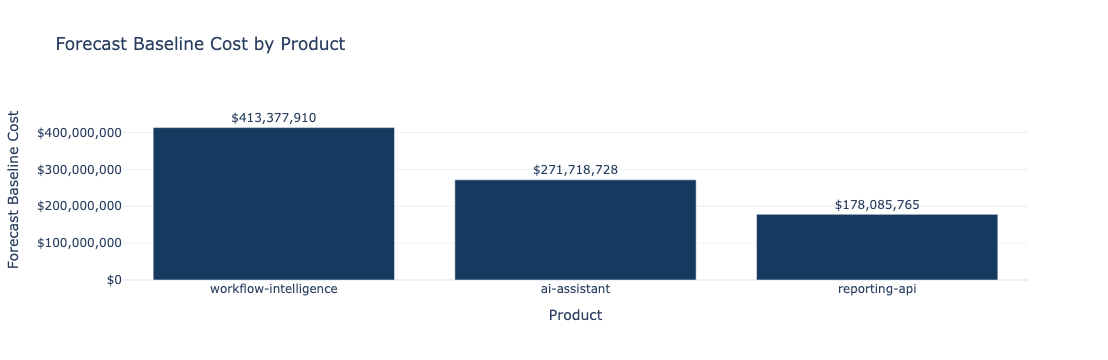

In [5]:
#plotly view of forecasted baseline cost, per product

forecast_by_product = (
    df.groupby("product_name", dropna=False)["forecast_baseline_cost"]
      .sum()
      .reset_index()
      .sort_values("forecast_baseline_cost", ascending=False)
)

fig = px.bar(
    forecast_by_product,
    x="product_name",
    y="forecast_baseline_cost",
    text="forecast_baseline_cost",
    title="Forecast Baseline Cost by Product"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    marker_color="#163A5F"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Product",
    yaxis_title="Forecast Baseline Cost",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.0f",
    showlegend=False
)

fig.show()

In [6]:
forecast_by_sla = (
    df.groupby("sla_tier")["forecast_baseline_cost"]
      .sum()
      .reset_index()
      .sort_values("forecast_baseline_cost", ascending=False)
)

forecast_by_sla


,sla_tier,forecast_baseline_cost
2,standard,3.756080e+08
1,premium,3.140796e+08
0,enterprise,1.734948e+08


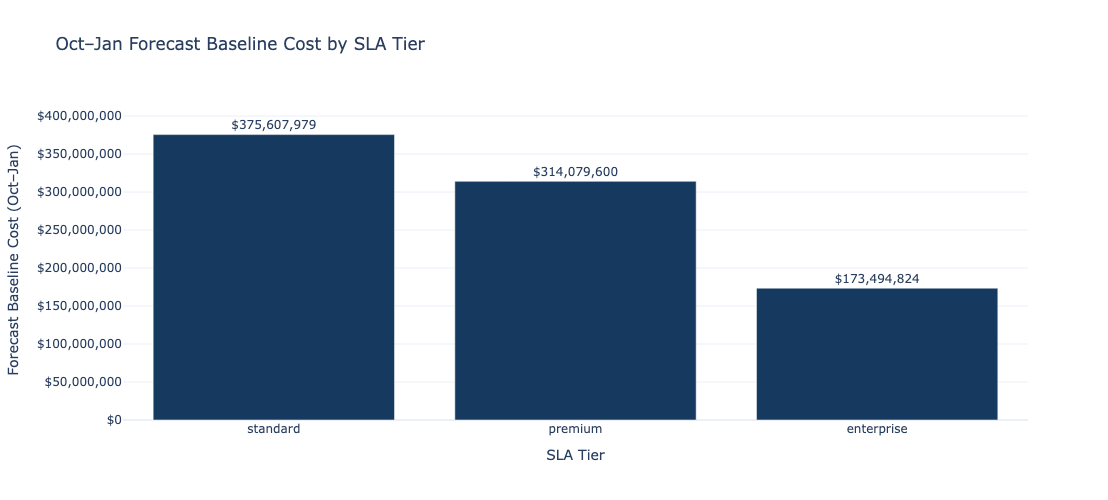

In [7]:
# view in dollars

fig = px.bar(
    forecast_by_sla,
    x="sla_tier",
    y="forecast_baseline_cost",
    text="forecast_baseline_cost",
    title="Oct–Jan Forecast Baseline Cost by SLA Tier",
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    marker_color="#163A5F",
    hovertemplate="<b>%{x}</b><br>Forecast Baseline Cost: $%{y:,.0f}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="SLA Tier",
    yaxis_title="Forecast Baseline Cost (Oct–Jan)",
    yaxis_tickformat="$,.0f",
    showlegend=False,
    height=500,
)

fig.show()

In [8]:
# check for what all columns are

df.columns.tolist()

['usage_date',
 'billing_period',
 'account_id',
 'account_name',
 'business_unit',
 'environment',
 'region',
 'service_name',
 'product_name',
 'team',
 'cost_usd',
 'usage_quantity',
 'usage_unit',
 'monthly_revenue_proxy',
 'active_customers',
 'workflows_processed',
 'enterprise_customer_flag',
 'sla_tier',
 'budget_amount',
 'forecast_baseline_cost',
 'acquisition_phase',
 'tag_owner',
 'tag_environment',
 'tag_product',
 'tag_cost_center',
 'allocation_status',
 'anomaly_flag']

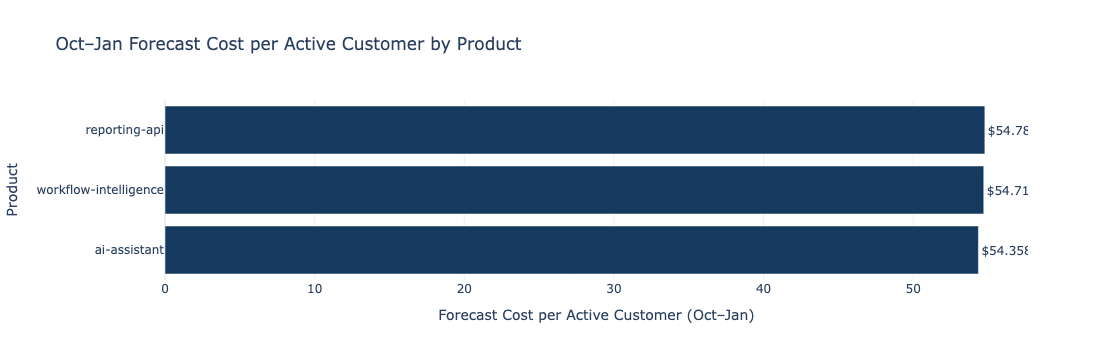

In [9]:
# checking cloud efficiency per customer

unit_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "active_customers": "sum",
      })
      .reset_index()
)

unit_df["cost_per_customer"] = (
    unit_df["forecast_baseline_cost"] / unit_df["active_customers"]
)

unit_df = unit_df.sort_values("cost_per_customer", ascending=True)

fig = px.bar(
    unit_df,
    x="cost_per_customer",
    y="product_name",
    orientation="h",
    text="cost_per_customer",
    title="Oct–Jan Forecast Cost per Active Customer by Product",
)

fig.update_traces(
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    marker_color="#163A5F",
    hovertemplate="<b>%{y}</b><br>Cost per customer: $%{x:,.4f}<extra></extra>",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Forecast Cost per Active Customer (Oct–Jan)",
    yaxis_title="Product",
    showlegend=False,
)

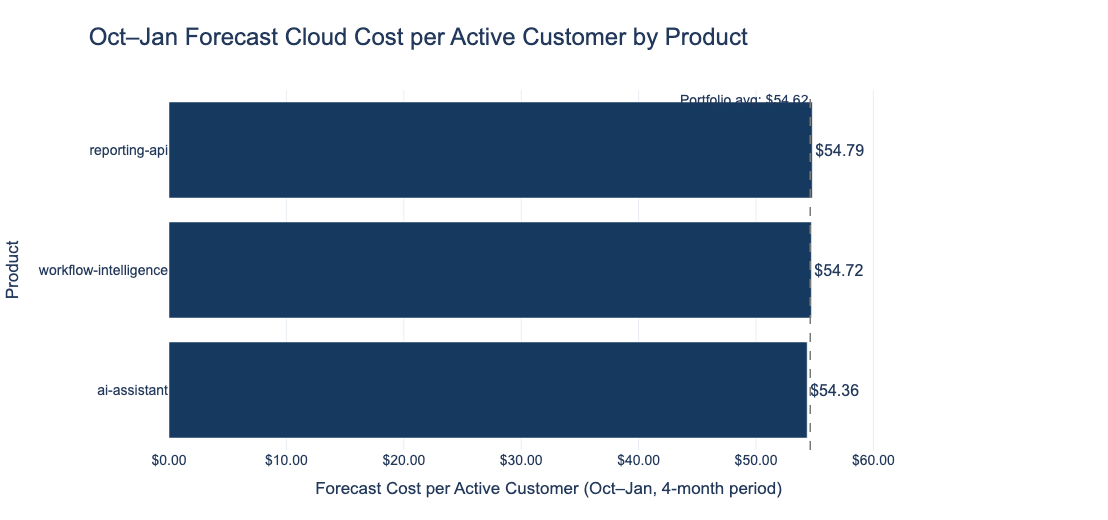

In [10]:
# better version

import numpy as np
import pandas as pd
import plotly.express as px

# Aggregate to product level
unit_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "active_customers": "sum",
      })
      .reset_index()
)

# Guard against divide-by-zero
unit_df = unit_df[unit_df["active_customers"] > 0].copy()

# Unit metric
unit_df["cost_per_customer"] = (
    unit_df["forecast_baseline_cost"] / unit_df["active_customers"]
)

# Sort for cleaner reading
unit_df = unit_df.sort_values("cost_per_customer", ascending=True)

# Portfolio average
portfolio_avg = unit_df["cost_per_customer"].mean()

fig = px.bar(
    unit_df,
    x="cost_per_customer",
    y="product_name",
    orientation="h",
    text="cost_per_customer",
    title="Oct–Jan Forecast Cloud Cost per Active Customer by Product",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.2f}",
    textposition="outside",
    cliponaxis=False,
    outsidetextfont=dict(size=16, color="#23395B"),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Forecast cost per active customer: $%{x:,.2f}"
        "<extra></extra>"
    ),
)

fig.add_vline(
    x=portfolio_avg,
    line_dash="dash",
    line_color="#7A7A7A",
    line_width=1.5,
    annotation_text=f"Portfolio avg: ${portfolio_avg:,.2f}",
    annotation_position="top left"
)

max_x = unit_df["cost_per_customer"].max()

fig.update_layout(
    template="plotly_white",
    height=520,
    showlegend=False,
    title=dict(
        x=0.08,
        xanchor="left",
        font=dict(size=24, color="#23395B")
    ),
    margin=dict(l=150, r=180, t=90, b=70),
    xaxis=dict(
        title="Forecast Cost per Active Customer (Oct–Jan, 4-month period)",
        tickprefix="$",
        tickformat=",.2f",
        showgrid=True,
        gridcolor="#E8EDF3",
        zeroline=False,
        range=[0, max_x * 1.18]
    ),
    yaxis=dict(
        title="Product",
        showgrid=False
    ),
    uniformtext_minsize=14,
    uniformtext_mode="show",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(
        family="Arial",
        size=14,
        color="#23395B"
    )
)

fig.show()

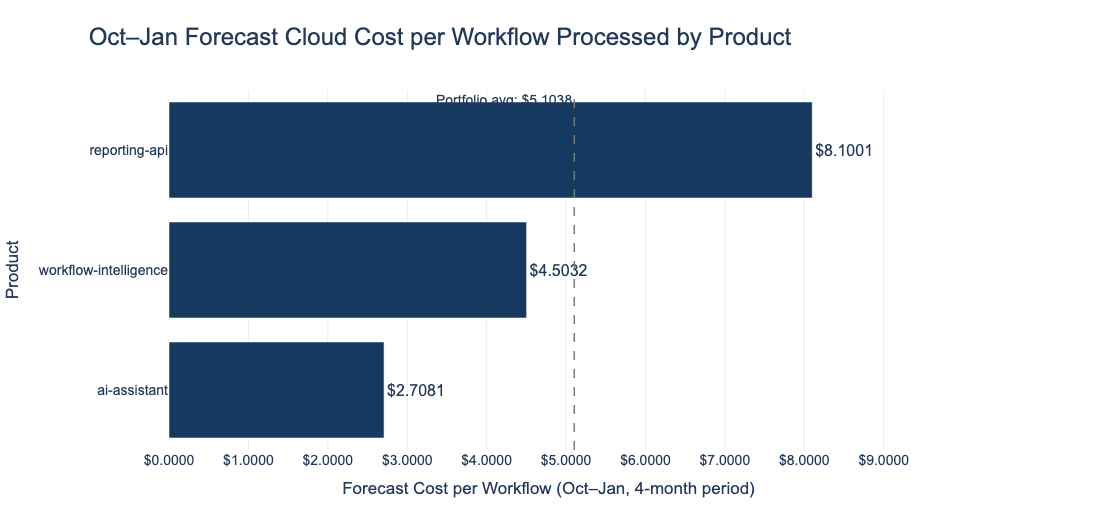

In [11]:
# checking cost per workflow processed

workflow_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

workflow_df = workflow_df[workflow_df["workflows_processed"] > 0].copy()

workflow_df["cost_per_workflow"] = (
    workflow_df["forecast_baseline_cost"] / workflow_df["workflows_processed"]
)

workflow_df = workflow_df.sort_values("cost_per_workflow", ascending=True)

workflow_avg = workflow_df["cost_per_workflow"].mean()

fig = px.bar(
    workflow_df,
    x="cost_per_workflow",
    y="product_name",
    orientation="h",
    text="cost_per_workflow",
    title="Oct–Jan Forecast Cloud Cost per Workflow Processed by Product",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    outsidetextfont=dict(size=16, color="#23395B"),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Forecast cost per workflow: $%{x:,.4f}"
        "<extra></extra>"
    ),
)

max_x = workflow_df["cost_per_workflow"].max()

fig.add_vline(
    x=workflow_avg,
    line_dash="dash",
    line_color="#7A7A7A",
    line_width=1.5,
    annotation_text=f"Portfolio avg: ${workflow_avg:,.4f}",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=520,
    showlegend=False,
    title=dict(x=0.08, xanchor="left", font=dict(size=24, color="#23395B")),
    margin=dict(l=150, r=180, t=90, b=70),
    xaxis=dict(
        title="Forecast Cost per Workflow (Oct–Jan, 4-month period)",
        tickprefix="$",
        tickformat=",.4f",
        showgrid=True,
        gridcolor="#E8EDF3",
        zeroline=False,
        range=[0, max_x * 1.18]
    ),
    yaxis=dict(title="Product", showgrid=False),
    uniformtext_minsize=14,
    uniformtext_mode="show",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=14, color="#23395B")
)

fig.show()

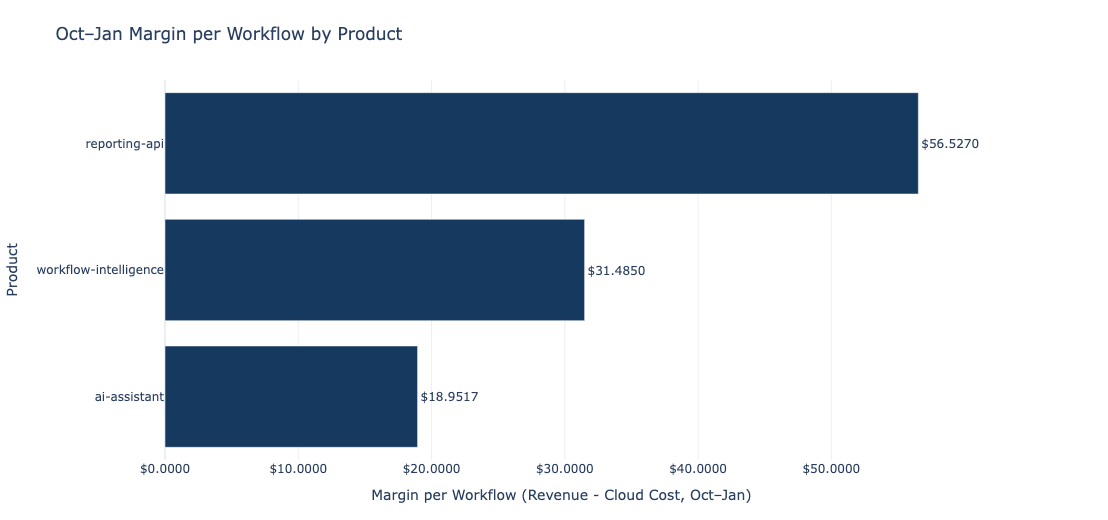

In [12]:
margin_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum"
      })
      .reset_index()
)

margin_df = margin_df[margin_df["workflows_processed"] > 0].copy()

margin_df["cost_per_workflow"] = (
    margin_df["forecast_baseline_cost"] / margin_df["workflows_processed"]
)

margin_df["revenue_per_workflow"] = (
    margin_df["monthly_revenue_proxy"] / margin_df["workflows_processed"]
)

margin_df["margin_per_workflow"] = (
    margin_df["revenue_per_workflow"] - margin_df["cost_per_workflow"]
)

margin_df = margin_df.sort_values("margin_per_workflow", ascending=True)

fig = px.bar(
    margin_df,
    x="margin_per_workflow",
    y="product_name",
    orientation="h",
    text="margin_per_workflow",
    title="Oct–Jan Margin per Workflow by Product"
)

fig.update_traces(
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    marker_color="#163A5F"
)

fig.update_layout(
    template="plotly_white",
    height=520,
    xaxis_title="Margin per Workflow (Revenue - Cloud Cost, Oct–Jan)",
    yaxis_title="Product",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.4f",
    showlegend=False,
    margin=dict(l=150, r=150, t=80, b=60)
)

fig.show()

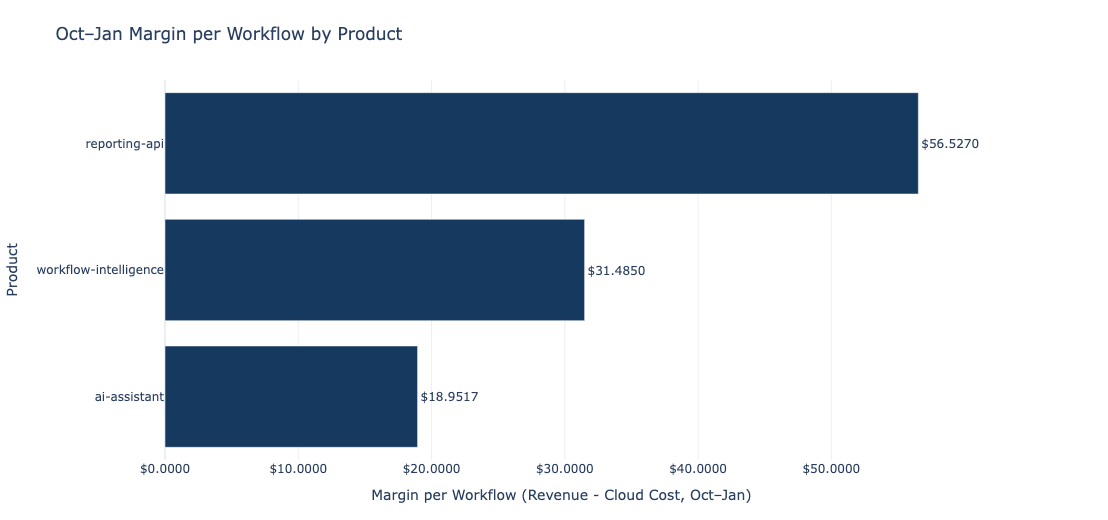

In [13]:
fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Margin per workflow: $%{x:,.4f}<extra></extra>"
)

fig.show()

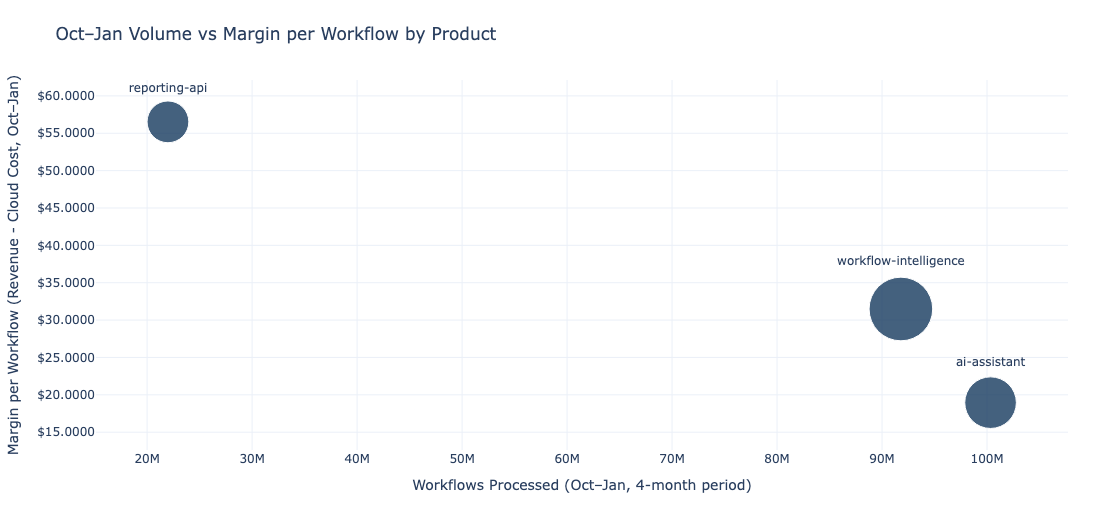

In [14]:

scatter_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

scatter_df = scatter_df[scatter_df["workflows_processed"] > 0].copy()

scatter_df["cost_per_workflow"] = (
    scatter_df["forecast_baseline_cost"] / scatter_df["workflows_processed"]
)

scatter_df["revenue_per_workflow"] = (
    scatter_df["monthly_revenue_proxy"] / scatter_df["workflows_processed"]
)

scatter_df["margin_per_workflow"] = (
    scatter_df["revenue_per_workflow"] - scatter_df["cost_per_workflow"]
)

fig = px.scatter(
    scatter_df,
    x="workflows_processed",
    y="margin_per_workflow",
    size="forecast_baseline_cost",
    size_max=45,
    text="product_name",
    title="Oct–Jan Volume vs Margin per Workflow by Product",
)

fig.update_traces(
    textposition="top center",
    marker=dict(color="#163A5F", opacity=0.8, line=dict(color="#ffffff", width=1)),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Workflows processed: %{x:,.0f}<br>"
        "Margin per workflow: $%{y:,.4f}<br>"
        "Forecast baseline cost: $%{marker.size:,.0f}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    template="plotly_white",
    height=520,
    xaxis_title="Workflows Processed (Oct–Jan, 4-month period)",
    yaxis_title="Margin per Workflow (Revenue - Cloud Cost, Oct–Jan)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.4f",
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=80, r=40, t=80, b=70),
)

fig.show()

In [15]:
# pursuing an "absolute economics view"

summary = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

summary["cost_per_workflow"] = summary["forecast_baseline_cost"] / summary["workflows_processed"]
summary["revenue_per_workflow"] = summary["monthly_revenue_proxy"] / summary["workflows_processed"]
summary["margin_per_workflow"] = summary["revenue_per_workflow"] - summary["cost_per_workflow"]

summary

,product_name,forecast_baseline_cost,monthly_revenue_proxy,workflows_processed,cost_per_workflow,revenue_per_workflow,margin_per_workflow
0,ai-assistant,2.717187e+08,2.173256e+09,100335822,2.708093,21.659824,18.951731
1,reporting-api,1.780858e+08,1.420863e+09,21985528,8.100136,64.627182,56.527046
2,workflow-intelligence,4.133779e+08,3.303570e+09,91795814,4.503233,35.988238,31.485005


In [16]:
# what if we double reporting-api workflows while keeping same efficiency

rep = summary[summary["product_name"] == "reporting-api"].iloc[0]

current_margin_total = rep["margin_per_workflow"] * rep["workflows_processed"]
double_volume_margin_total = rep["margin_per_workflow"] * (rep["workflows_processed"] * 2)

current_margin_total, double_volume_margin_total

(np.float64(1242776956.78), np.float64(2485553913.56))

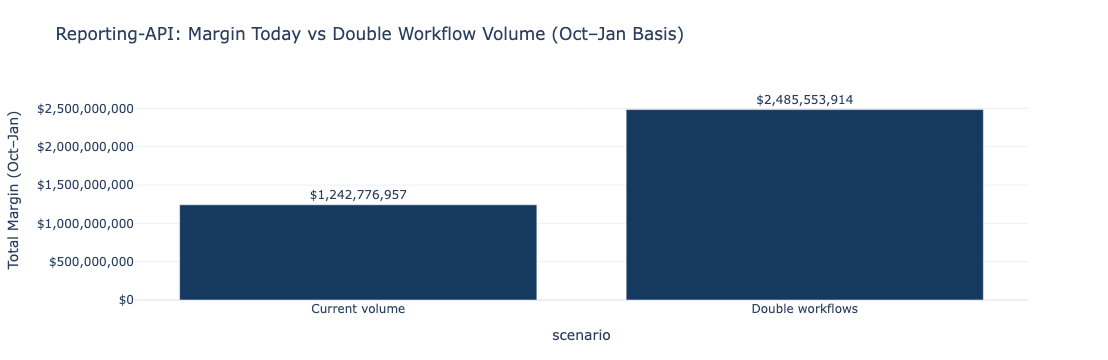

In [17]:
# visualizing the doubling 

rep = summary[summary["product_name"] == "reporting-api"].iloc[0]

current_margin_total = rep["margin_per_workflow"] * rep["workflows_processed"]
double_volume_margin_total = rep["margin_per_workflow"] * (rep["workflows_processed"] * 2)

scenario_df = pd.DataFrame({
    "scenario": ["Current volume", "Double workflows"],
    "total_margin": [current_margin_total, double_volume_margin_total],
})

fig = px.bar(
    scenario_df,
    x="scenario",
    y="total_margin",
    text="total_margin",
    title="Reporting-API: Margin Today vs Double Workflow Volume (Oct–Jan Basis)"
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    template="plotly_white",
    yaxis_title="Total Margin (Oct–Jan)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.0f",
    showlegend=False,
    margin=dict(l=80, r=80, t=80, b=60),
)

fig.show()

In [18]:
# checking the relationship between enterprise product and reporting-api

ent = (
    df.groupby(["product_name", "enterprise_customer_flag"], dropna=False)
      .agg({
          "workflows_processed": "sum",
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
      })
      .reset_index()
)

ent

,product_name,enterprise_customer_flag,workflows_processed,forecast_baseline_cost,monthly_revenue_proxy
0,ai-assistant,0,68972574,1.879987e+08,1.505019e+09
1,ai-assistant,1,31363248,8.372007e+07,6.682370e+08
2,reporting-api,0,15264489,1.223379e+08,9.801755e+08
3,reporting-api,1,6721039,5.574788e+07,4.406872e+08
4,workflow-intelligence,0,63828316,2.832110e+08,2.273909e+09
5,workflow-intelligence,1,27967498,1.301669e+08,1.029661e+09


In [19]:
# unit economics for enterprise vs non-enterprise

ent = ent[ent["workflows_processed"] > 0].copy()

ent["cost_per_workflow"] = (
    ent["forecast_baseline_cost"] / ent["workflows_processed"]
)
ent["revenue_per_workflow"] = (
    ent["monthly_revenue_proxy"] / ent["workflows_processed"]
)
ent["margin_per_workflow"] = (
    ent["revenue_per_workflow"] - ent["cost_per_workflow"]
)

In [20]:
ent_reporting = ent[
    (ent["product_name"] == "reporting-api") &
    (ent["enterprise_customer_flag"] == True)
]
ent_reporting

,product_name,enterprise_customer_flag,workflows_processed,forecast_baseline_cost,monthly_revenue_proxy,cost_per_workflow,revenue_per_workflow,margin_per_workflow
3,reporting-api,1,6721039,55747880.32,4.406872e+08,8.294533,65.568319,57.273786


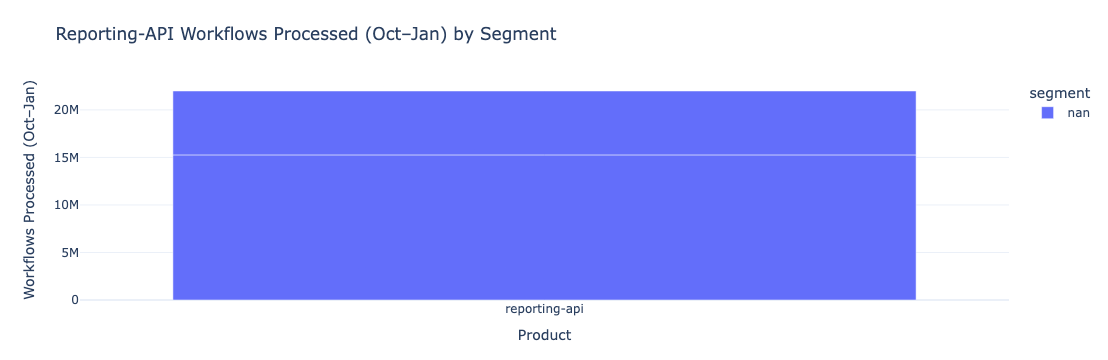

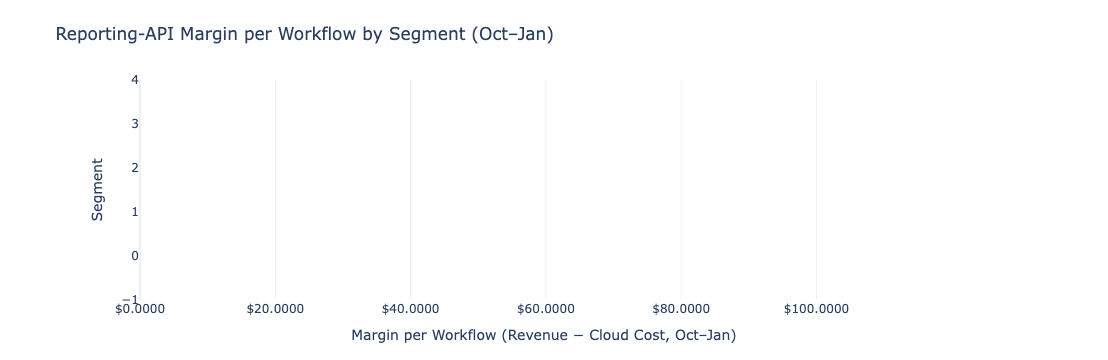

In [21]:
#visualizing enterprise vs non-enterprise

import pandas as pd
import plotly.express as px

# 1) Aggregate by product + enterprise flag
ent = (
    df.groupby(["product_name", "enterprise_customer_flag"], dropna=False)
      .agg({
          "workflows_processed": "sum",
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
      })
      .reset_index()
)

# 2) Keep only reporting-api and non-zero workflows
ent_rep = ent[
    (ent["product_name"] == "reporting-api") &
    (ent["workflows_processed"] > 0)
].copy()

# 3) Compute unit economics
ent_rep["segment"] = ent_rep["enterprise_customer_flag"].map(
    {True: "Enterprise", False: "Non-enterprise", 1: "Enterprise", 0: "Non-enterprise"}
)

ent_rep["cost_per_workflow"] = (
    ent_rep["forecast_baseline_cost"] / ent_rep["workflows_processed"]
)
ent_rep["revenue_per_workflow"] = (
    ent_rep["monthly_revenue_proxy"] / ent_rep["workflows_processed"]
)
ent_rep["margin_per_workflow"] = (
    ent_rep["revenue_per_workflow"] - ent_rep["cost_per_workflow"]
)

# --- Chart A: workflows by segment (stacked bar) ---

fig_vol = px.bar(
    ent_rep,
    x=["reporting-api", "reporting-api"],
    y="workflows_processed",
    color="segment",
    title="Reporting-API Workflows Processed (Oct–Jan) by Segment",
    labels={"x": "Product", "workflows_processed": "Workflows Processed (Oct–Jan)"},
)

fig_vol.update_traces(
    hovertemplate="<b>%{customdata}</b><br>Workflows: %{y:,.0f}<extra></extra>",
    customdata=ent_rep["segment"],
)

fig_vol.update_layout(
    template="plotly_white",
    showlegend=True,
    xaxis_title="Product",
    yaxis_title="Workflows Processed (Oct–Jan)",
    margin=dict(l=80, r=40, t=80, b=60),
)

fig_vol.show()

# --- Chart B: margin per workflow by segment ---

fig_margin = px.bar(
    ent_rep.sort_values("margin_per_workflow", ascending=True),
    x="margin_per_workflow",
    y="segment",
    orientation="h",
    text="margin_per_workflow",
    title="Reporting-API Margin per Workflow by Segment (Oct–Jan)",
)

fig_margin.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Margin per workflow: $%{x:,.4f}<br>"
        "Revenue per workflow: $%{customdata[0]:,.4f}<br>"
        "Cost per workflow:    $%{customdata[1]:,.4f}"
        "<extra></extra>"
    ),
    customdata=ent_rep[["revenue_per_workflow", "cost_per_workflow"]].to_numpy(),
)

fig_margin.update_layout(
    template="plotly_white",
    xaxis_title="Margin per Workflow (Revenue − Cloud Cost, Oct–Jan)",
    yaxis_title="Segment",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.4f",
    showlegend=False,
    margin=dict(l=140, r=160, t=80, b=60),
)

fig_margin.show()

In [22]:
df["enterprise_customer_flag"].value_counts(dropna=False)

enterprise_customer_flag
0    3458
1    1542
Name: count, dtype: int64

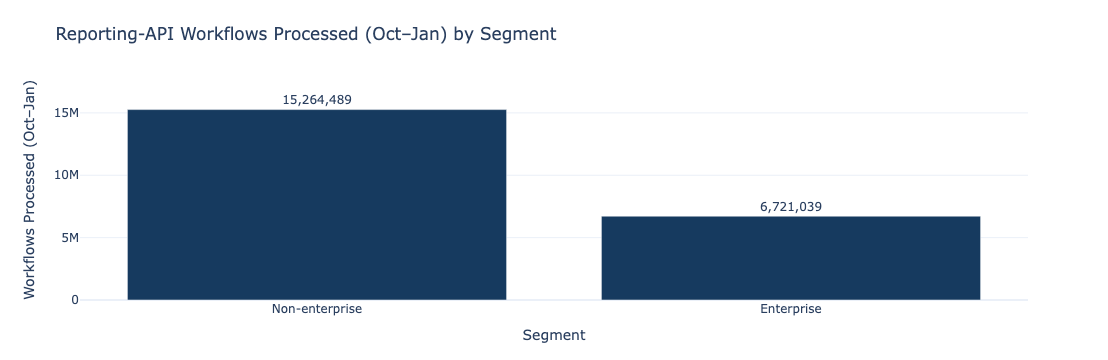

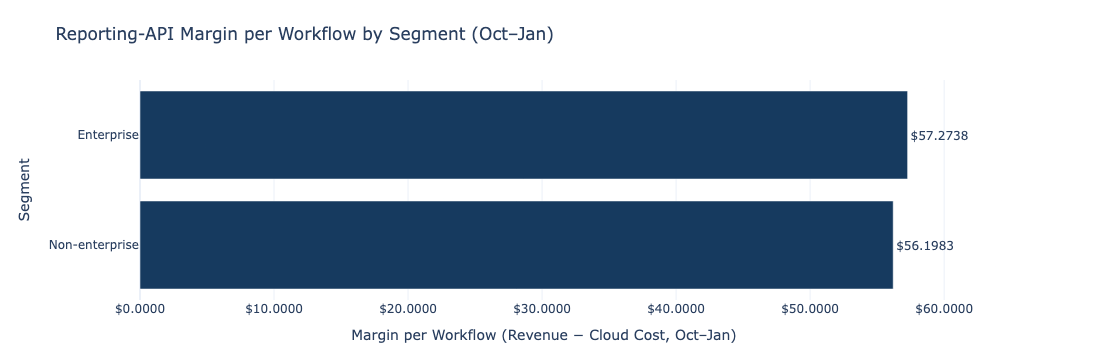

In [23]:
import numpy as np
import pandas as pd
import plotly.express as px

# Aggregate by product + enterprise flag
ent = (
    df.groupby(["product_name", "enterprise_customer_flag"], dropna=False)
      .agg({
          "workflows_processed": "sum",
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
      })
      .reset_index()
)

# Keep reporting-api only and non-zero workflows
ent_rep = ent[
    (ent["product_name"] == "reporting-api") &
    (ent["workflows_processed"] > 0)
].copy()

# Normalize the flag -> segment label
def to_segment(v):
    if pd.isna(v):
        return "Unknown"
    if v in [True, 1, "Y", "y", "Yes", "yes", "TRUE"]:
        return "Enterprise"
    if v in [False, 0, "N", "n", "No", "no", "FALSE"]:
        return "Non-enterprise"
    return str(v)

ent_rep["segment"] = ent_rep["enterprise_customer_flag"].apply(to_segment)

# If you only want Enterprise vs Non-enterprise, drop or group "Unknown" explicitly
ent_rep = ent_rep[ent_rep["segment"].isin(["Enterprise", "Non-enterprise"])].copy()

# Compute unit economics
ent_rep["cost_per_workflow"] = (
    ent_rep["forecast_baseline_cost"] / ent_rep["workflows_processed"]
)
ent_rep["revenue_per_workflow"] = (
    ent_rep["monthly_revenue_proxy"] / ent_rep["workflows_processed"]
)
ent_rep["margin_per_workflow"] = (
    ent_rep["revenue_per_workflow"] - ent_rep["cost_per_workflow"]
)

# --- Chart A: workflows by segment (simple bar) ---
fig_vol = px.bar(
    ent_rep,
    x="segment",
    y="workflows_processed",
    text="workflows_processed",
    title="Reporting-API Workflows Processed (Oct–Jan) by Segment",
)

fig_vol.update_traces(
    marker_color="#163A5F",
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{x}</b><br>Workflows: %{y:,.0f}<extra></extra>",
)

fig_vol.update_layout(
    template="plotly_white",
    xaxis_title="Segment",
    yaxis_title="Workflows Processed (Oct–Jan)",
    showlegend=False,
    margin=dict(l=80, r=80, t=80, b=60),
)

fig_vol.show()

# --- Chart B: margin per workflow by segment ---
fig_margin = px.bar(
    ent_rep.sort_values("margin_per_workflow", ascending=True),
    x="margin_per_workflow",
    y="segment",
    orientation="h",
    text="margin_per_workflow",
    title="Reporting-API Margin per Workflow by Segment (Oct–Jan)",
)

fig_margin.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Margin per workflow: $%{x:,.4f}<br>"
        "Revenue per workflow: $%{customdata[0]:,.4f}<br>"
        "Cost per workflow:    $%{customdata[1]:,.4f}"
        "<extra></extra>"
    ),
    customdata=ent_rep[["revenue_per_workflow", "cost_per_workflow"]].to_numpy(),
)

fig_margin.update_layout(
    template="plotly_white",
    xaxis_title="Margin per Workflow (Revenue − Cloud Cost, Oct–Jan)",
    yaxis_title="Segment",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.4f",
    showlegend=False,
    margin=dict(l=140, r=160, t=80, b=60),
)

fig_margin.show()

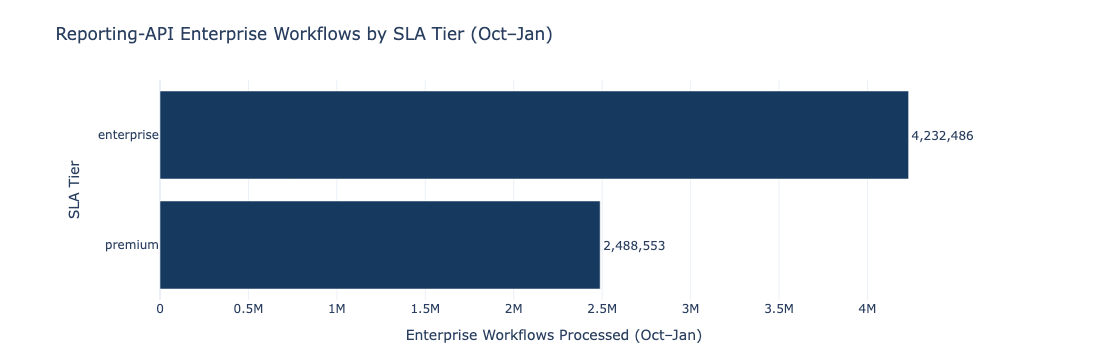

In [24]:
# Filter to reporting-api, enterprise only
rep_ent_sla = (
    df[
        (df["product_name"] == "reporting-api") &
        (df["enterprise_customer_flag"] == True)
    ]
    .groupby("sla_tier", dropna=False)
    .agg({
        "workflows_processed": "sum",
        "forecast_baseline_cost": "sum",
        "monthly_revenue_proxy": "sum",
    })
    .reset_index()
)

rep_ent_sla = rep_ent_sla[rep_ent_sla["workflows_processed"] > 0].copy()

# Unit economics by SLA tier
rep_ent_sla["cost_per_workflow"] = (
    rep_ent_sla["forecast_baseline_cost"] / rep_ent_sla["workflows_processed"]
)
rep_ent_sla["revenue_per_workflow"] = (
    rep_ent_sla["monthly_revenue_proxy"] / rep_ent_sla["workflows_processed"]
)
rep_ent_sla["margin_per_workflow"] = (
    rep_ent_sla["revenue_per_workflow"] - rep_ent_sla["cost_per_workflow"]
)

# Sort by workflows to see dominant SLA tier at a glance
rep_ent_sla = rep_ent_sla.sort_values("workflows_processed", ascending=True)

fig_sla = px.bar(
    rep_ent_sla,
    x="workflows_processed",
    y="sla_tier",
    orientation="h",
    text="workflows_processed",
    title="Reporting-API Enterprise Workflows by SLA Tier (Oct–Jan)",
)

fig_sla.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
    marker_color="#163A5F",
    hovertemplate=(
        "<b>SLA tier: %{y}</b><br>"
        "Workflows: %{x:,.0f}<br>"
        "Cost per workflow: $%{customdata[0]:,.4f}<br>"
        "Revenue per workflow: $%{customdata[1]:,.4f}<br>"
        "Margin per workflow: $%{customdata[2]:,.4f}"
        "<extra></extra>"
    ),
    customdata=rep_ent_sla[
        ["cost_per_workflow", "revenue_per_workflow", "margin_per_workflow"]
    ].to_numpy(),
)

fig_sla.update_layout(
    template="plotly_white",
    xaxis_title="Enterprise Workflows Processed (Oct–Jan)",
    yaxis_title="SLA Tier",
    showlegend=False,
    margin=dict(l=160, r=160, t=80, b=60),
)

fig_sla.show()

In [25]:
# checking time series for cost first


df["usage_date"] = pd.to_datetime(df["usage_date"])
df["month"] = df["usage_date"].dt.to_period("M").dt.to_timestamp()

In [26]:
# cost per workflow over time

monthly = (
    df.groupby("month", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

monthly = monthly[monthly["workflows_processed"] > 0].copy()

monthly["cost_per_workflow"] = (
    monthly["forecast_baseline_cost"] / monthly["workflows_processed"]
)

monthly

,month,forecast_baseline_cost,workflows_processed,cost_per_workflow
0,2025-10-01,2.152951e+08,54215840,3.971074
1,2025-11-01,2.080368e+08,49184500,4.229722
2,2025-12-01,2.197793e+08,51471168,4.269949
3,2026-01-01,2.200713e+08,59245656,3.714556


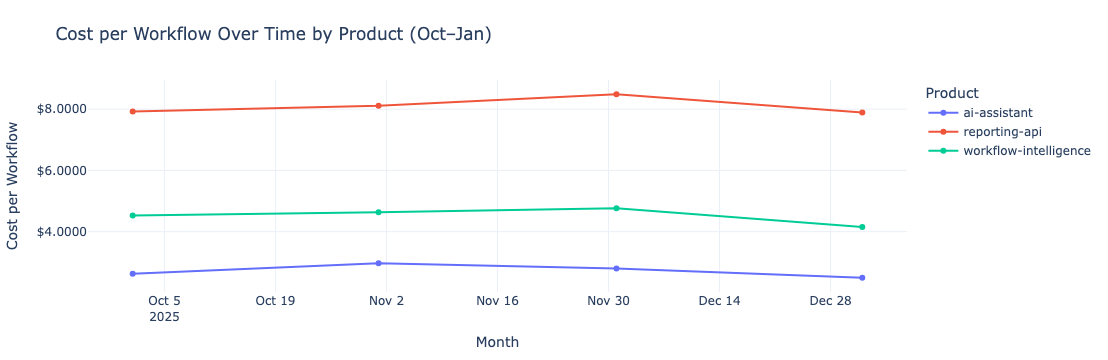

In [27]:
# is unit efficiency changing per product

monthly_prod = (
    df.groupby(["month", "product_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

monthly_prod = monthly_prod[monthly_prod["workflows_processed"] > 0].copy()

monthly_prod["cost_per_workflow"] = (
    monthly_prod["forecast_baseline_cost"] / monthly_prod["workflows_processed"]
)

fig = px.line(
    monthly_prod,
    x="month",
    y="cost_per_workflow",
    color="product_name",
    markers=True,
    title="Cost per Workflow Over Time by Product (Oct–Jan)",
)

fig.update_traces(
    hovertemplate=(
        "<b>%{x|%Y-%m}</b><br>"
        "%{legendgroup}: $%{y:,.4f} per workflow"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Cost per Workflow",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.4f",
    margin=dict(l=80, r=200, t=80, b=60),
    legend_title="Product",
)

fig.show()

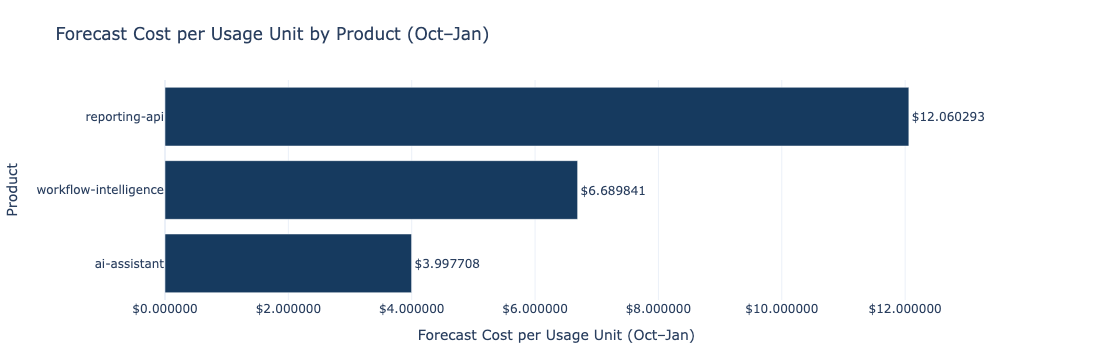

In [28]:
# checking cost per usage unit

import pandas as pd
import plotly.express as px

usage_prod = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
)

usage_prod = usage_prod[usage_prod["usage_quantity"] > 0].copy()
usage_prod["cost_per_usage_unit"] = (
    usage_prod["forecast_baseline_cost"] / usage_prod["usage_quantity"]
)

fig = px.bar(
    usage_prod.sort_values("cost_per_usage_unit", ascending=True),
    x="cost_per_usage_unit",
    y="product_name",
    orientation="h",
    text="cost_per_usage_unit",
    title="Forecast Cost per Usage Unit by Product (Oct–Jan)",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.6f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>Cost per usage unit: $%{x:,.6f}<extra></extra>",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Forecast Cost per Usage Unit (Oct–Jan)",
    yaxis_title="Product",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.6f",
    showlegend=False,
    margin=dict(l=150, r=160, t=80, b=60),
)

fig.show()

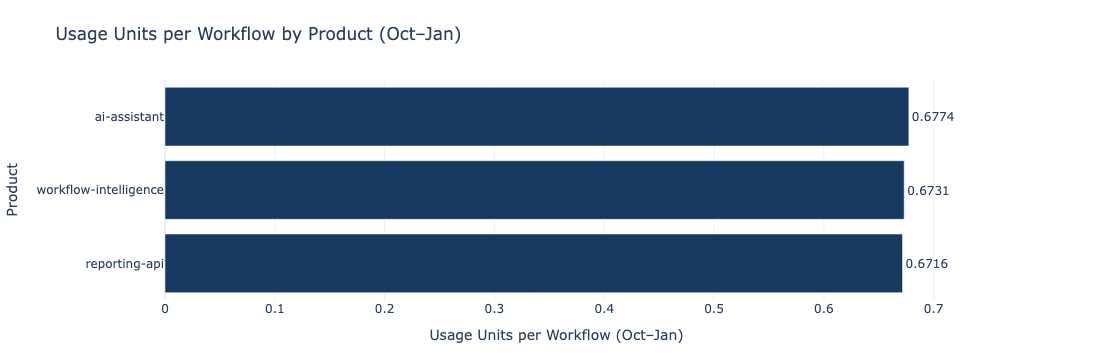

In [29]:
# checking usage units per workflow

usage_intensity = (
    df.groupby("product_name", dropna=False)
      .agg({
          "usage_quantity": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

usage_intensity = usage_intensity[usage_intensity["workflows_processed"] > 0].copy()

usage_intensity["usage_per_workflow"] = (
    usage_intensity["usage_quantity"] / usage_intensity["workflows_processed"]
)

fig = px.bar(
    usage_intensity.sort_values("usage_per_workflow", ascending=True),
    x="usage_per_workflow",
    y="product_name",
    orientation="h",
    text="usage_per_workflow",
    title="Usage Units per Workflow by Product (Oct–Jan)",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>Usage per workflow: %{x:,.4f} %{customdata}<extra></extra>",
    customdata=df["usage_unit"].mode()  # simple placeholder if unit is consistent
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Usage Units per Workflow (Oct–Jan)",
    yaxis_title="Product",
    showlegend=False,
    margin=dict(l=150, r=160, t=80, b=60),
)

fig.show()

In [30]:
# service usage for reproting api

svc_usage = (
    df.groupby(["product_name", "service_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
)

svc_usage = svc_usage[svc_usage["usage_quantity"] > 0].copy()
svc_usage["cost_per_usage_unit"] = (
    svc_usage["forecast_baseline_cost"] / svc_usage["usage_quantity"]
)

svc_usage[svc_usage["product_name"] == "reporting-api"].sort_values(
    "cost_per_usage_unit", ascending=False
).head(10)

,product_name,service_name,forecast_baseline_cost,usage_quantity,cost_per_usage_unit
23,reporting-api,Support / Shared Platform,12785600.58,186991.24,68.375399
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362
21,reporting-api,Data Transfer,16975687.15,1371404.54,12.378322
22,reporting-api,NAT Gateway,14471126.93,1174574.17,12.320318
16,reporting-api,Amazon CloudWatch,15506842.73,1451879.30,10.680532
14,reporting-api,AWS Lambda,15829743.55,1716627.12,9.221422
19,reporting-api,Amazon RDS,15287133.55,1695381.66,9.016928
17,reporting-api,Amazon EBS,15173699.16,1818031.22,8.346226


In [31]:
#checking service usage for each prodcut now

svc_usage_all = (
    df.groupby(["product_name", "service_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
)

svc_usage_all = svc_usage_all[svc_usage_all["usage_quantity"] > 0].copy()
svc_usage_all["cost_per_usage_unit"] = (
    svc_usage_all["forecast_baseline_cost"] / svc_usage_all["usage_quantity"]
)

svc_usage_all.sort_values("cost_per_usage_unit", ascending=False).head(20)

,product_name,service_name,forecast_baseline_cost,usage_quantity,cost_per_usage_unit
23,reporting-api,Support / Shared Platform,12785600.58,186991.24,68.375399
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
35,workflow-intelligence,Support / Shared Platform,34418752.45,955003.78,36.040436
27,workflow-intelligence,Amazon Athena,36578268.80,1435076.16,25.488730
25,workflow-intelligence,AWS Glue,31789457.37,1320807.51,24.068199
11,ai-assistant,Support / Shared Platform,25294318.61,1105226.78,22.886089
3,ai-assistant,Amazon Athena,19418893.73,1278343.39,15.190671
1,ai-assistant,AWS Glue,22083310.50,1483717.86,14.883767
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362


In [32]:
# getting to a visual for key services

key_services = [
    "Support / Shared Platform",
    "Amazon Athena",
    "AWS Glue",
    "Amazon S3",
    "Data Transfer",
    "NAT Gateway",
]

svc_selected = svc_usage_all[svc_usage_all["service_name"].isin(key_services)].copy()

# Only keep reasonably sized services if you want
svc_selected = svc_selected.sort_values(
    ["service_name", "product_name"]
)

svc_selected

,product_name,service_name,forecast_baseline_cost,usage_quantity,cost_per_usage_unit
1,ai-assistant,AWS Glue,22083310.50,1483717.86,14.883767
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
25,workflow-intelligence,AWS Glue,31789457.37,1320807.51,24.068199
3,ai-assistant,Amazon Athena,19418893.73,1278343.39,15.190671
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
27,workflow-intelligence,Amazon Athena,36578268.80,1435076.16,25.488730
8,ai-assistant,Amazon S3,23441100.57,5619912.87,4.171079
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362
32,workflow-intelligence,Amazon S3,32557624.89,4311007.99,7.552207
9,ai-assistant,Data Transfer,22234447.40,5296556.80,4.197906


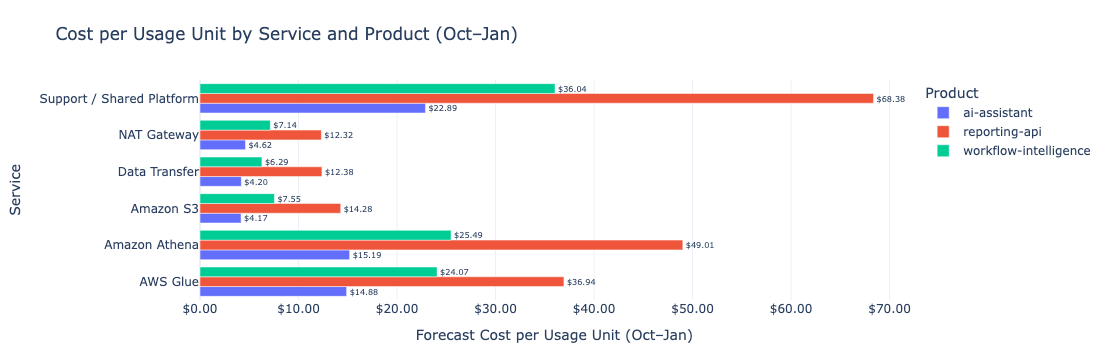

In [33]:
# visualizing


fig = px.bar(
    svc_selected,
    x="cost_per_usage_unit",
    y="service_name",
    color="product_name",
    barmode="group",
    orientation="h",
    text="cost_per_usage_unit",
    title="Cost per Usage Unit by Service and Product (Oct–Jan)",
)

fig.update_traces(
    texttemplate="$%{text:,.2f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Product: %{legendgroup}<br>"
        "Cost per usage unit: $%{x:,.4f}<br>"
        "<extra></extra>"
    ),
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Forecast Cost per Usage Unit (Oct–Jan)",
    yaxis_title="Service",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.2f",
    margin=dict(l=200, r=160, t=80, b=60),
    legend_title="Product",
)

fig.show()

In [34]:
# now to create a single, simple method for baseline analysis

import pandas as pd

# 0) Ensure dates and a month key
df["usage_date"] = pd.to_datetime(df["usage_date"])
df["billing_period"] = pd.to_datetime(df["billing_period"])
df["month"] = df["usage_date"].dt.to_period("M").dt.to_timestamp()

# 1) Baseline by month (forecast vs actual)
baseline_monthly = (
    df.groupby("month", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
      })
      .reset_index()
      .rename(columns={
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

baseline_monthly["forecast_vs_actual_delta"] = (
    baseline_monthly["forecast_cost_usd"] - baseline_monthly["actual_cost_usd"]
)

# 2) By product: totals + unit economics
by_product = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
          "active_customers": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
      .rename(columns={
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

# Guard against zeros
by_product = by_product[
    (by_product["workflows_processed"] > 0) &
    (by_product["active_customers"] > 0) &
    (by_product["usage_quantity"] > 0)
].copy()

by_product["cost_per_workflow"] = (
    by_product["forecast_cost_usd"] / by_product["workflows_processed"]
)
by_product["revenue_per_workflow"] = (
    by_product["monthly_revenue_proxy"] / by_product["workflows_processed"]
)
by_product["margin_per_workflow"] = (
    by_product["revenue_per_workflow"] - by_product["cost_per_workflow"]
)

by_product["cost_per_customer"] = (
    by_product["forecast_cost_usd"] / by_product["active_customers"]
)
by_product["cost_per_usage_unit"] = (
    by_product["forecast_cost_usd"] / by_product["usage_quantity"]
)
by_product["usage_units_per_workflow"] = (
    by_product["usage_quantity"] / by_product["workflows_processed"]
)

# 3) Spend by environment + product
# Prefer tag_environment if it is more complete; fallback to environment
env_col = "tag_environment" if df["tag_environment"].notna().any() else "environment"

by_env_product = (
    df.groupby([env_col, "product_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
      })
      .reset_index()
      .rename(columns={
          env_col: "environment",
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

# 4) Spend by account (maps to acquired-ai-platform, legacy-core-prod, shared-services)
by_account = (
    df.groupby(["account_id", "account_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
      })
      .reset_index()
      .rename(columns={
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

# 5) Service usage by product (for per-unit cost analysis)
service_usage = (
    df.groupby(["product_name", "service_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
      .rename(columns={"forecast_baseline_cost": "forecast_cost_usd"})
)

service_usage = service_usage[service_usage["usage_quantity"] > 0].copy()
service_usage["cost_per_usage_unit"] = (
    service_usage["forecast_cost_usd"] / service_usage["usage_quantity"]
)

# Optional: quick views
display(baseline_monthly)
display(by_product.sort_values("forecast_cost_usd", ascending=False))
display(by_env_product.sort_values("forecast_cost_usd", ascending=False).head(20))
display(by_account.sort_values("forecast_cost_usd", ascending=False))
display(service_usage.sort_values("cost_per_usage_unit", ascending=False).head(20))

,month,forecast_cost_usd,actual_cost_usd,forecast_vs_actual_delta
0,2025-10-01,2.152951e+08,22003.75,2.152731e+08
1,2025-11-01,2.080368e+08,24096.05,2.080127e+08
2,2025-12-01,2.197793e+08,28912.71,2.197504e+08
3,2026-01-01,2.200713e+08,35007.89,2.200363e+08


,product_name,forecast_cost_usd,actual_cost_usd,monthly_revenue_proxy,workflows_processed,active_customers,usage_quantity,cost_per_workflow,revenue_per_workflow,margin_per_workflow,cost_per_customer,cost_per_usage_unit,usage_units_per_workflow
2,workflow-intelligence,4.133779e+08,47452.29,3.303570e+09,91795814,7554934,61791885.94,4.503233,35.988238,31.485005,54.716283,6.689841,0.673145
0,ai-assistant,2.717187e+08,51472.71,2.173256e+09,100335822,4998670,67968635.76,2.708093,21.659824,18.951731,54.358205,3.997708,0.677411
1,reporting-api,1.780858e+08,11095.40,1.420863e+09,21985528,3250402,14766288.86,8.100136,64.627182,56.527046,54.788843,12.060293,0.671637


,environment,product_name,forecast_cost_usd,actual_cost_usd
5,prod,workflow-intelligence,1.534564e+08,27800.27
14,staging,workflow-intelligence,1.188062e+08,10452.23
2,dev,workflow-intelligence,1.166323e+08,5653.56
3,prod,ai-assistant,9.646834e+07,30456.66
12,staging,ai-assistant,8.267510e+07,12579.58
0,dev,ai-assistant,7.549600e+07,5859.98
4,prod,reporting-api,6.339194e+07,6767.21
13,staging,reporting-api,5.778789e+07,2508.31
1,dev,reporting-api,4.527625e+07,1150.51
11,stage,workflow-intelligence,1.054045e+07,1655.58


,account_id,account_name,forecast_cost_usd,actual_cost_usd
0,1001,legacy-core-prod,2.955491e+08,35971.40
1,1002,acquired-ai-platform,2.883953e+08,39302.82
2,1003,shared-services,2.792380e+08,34746.18


,product_name,service_name,forecast_cost_usd,usage_quantity,cost_per_usage_unit
23,reporting-api,Support / Shared Platform,12785600.58,186991.24,68.375399
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
35,workflow-intelligence,Support / Shared Platform,34418752.45,955003.78,36.040436
27,workflow-intelligence,Amazon Athena,36578268.80,1435076.16,25.488730
25,workflow-intelligence,AWS Glue,31789457.37,1320807.51,24.068199
11,ai-assistant,Support / Shared Platform,25294318.61,1105226.78,22.886089
3,ai-assistant,Amazon Athena,19418893.73,1278343.39,15.190671
1,ai-assistant,AWS Glue,22083310.50,1483717.86,14.883767
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362


In [35]:
# unit economics summary

unit_summary = by_product[[
    "product_name",
    "forecast_cost_usd",
    "monthly_revenue_proxy",
    "workflows_processed",
    "active_customers",
    "cost_per_workflow",
    "revenue_per_workflow",
    "margin_per_workflow",
    "cost_per_customer",
    "cost_per_usage_unit",
    "usage_units_per_workflow",
]].sort_values("margin_per_workflow", ascending=False)

unit_summary

,product_name,forecast_cost_usd,monthly_revenue_proxy,workflows_processed,active_customers,cost_per_workflow,revenue_per_workflow,margin_per_workflow,cost_per_customer,cost_per_usage_unit,usage_units_per_workflow
1,reporting-api,1.780858e+08,1.420863e+09,21985528,3250402,8.100136,64.627182,56.527046,54.788843,12.060293,0.671637
2,workflow-intelligence,4.133779e+08,3.303570e+09,91795814,7554934,4.503233,35.988238,31.485005,54.716283,6.689841,0.673145
0,ai-assistant,2.717187e+08,2.173256e+09,100335822,4998670,2.708093,21.659824,18.951731,54.358205,3.997708,0.677411


In [36]:
from pyathena import connect
import pandas as pd

region = "us-east-1"
s3_staging_dir = "s3://clarionflow-ai-finops-data/athena-results/"
database = "clarionflow-ai-finops"

conn = connect(
    s3_staging_dir=s3_staging_dir,
    region_name=region,
    schema_name=database,
)

In [37]:
import boto3
from pyathena import connect
import pandas as pd

profile = "finops-dojo"
region = "us-east-1"          
s3_staging_dir = "s3://clarionflow-ai-finops-data/athena-results/"
database = "clarionflow-ai-finops"

session = boto3.Session(profile_name=profile, region_name=region)

conn = connect(
    s3_staging_dir=s3_staging_dir,
    region_name=region,
    schema_name=database,
    aws_access_key_id=session.get_credentials().access_key,
    aws_secret_access_key=session.get_credentials().secret_key,
    aws_session_token=session.get_credentials().token,
)

In [38]:
sql = """
SELECT environment,
       SUM(cost_usd) AS cost_usd
FROM billing_case01
GROUP BY environment
ORDER BY cost_usd DESC
"""

df_env = pd.read_sql(sql, conn)
df_env

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/4035935106.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_env = pd.read_sql(sql, conn)


,environment,cost_usd
0,product-analytics,39770361.58
1,ml-engineering,36209225.31
2,platform,34470546.52
3,data,34076677.15


In [39]:
sql = """
SELECT
    account_name,
    environment,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
GROUP BY account_name, environment
ORDER BY cost_usd DESC
"""

df_env = pd.read_sql(sql, conn)
df_env

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/917264876.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_env = pd.read_sql(sql, conn)


,account_name,environment,cost_usd
0,ai-products,product-analytics,13864800.85
1,core-platform,product-analytics,13510563.95
2,ai-products,ml-engineering,12441324.76
3,core-platform,ml-engineering,12399468.91
4,shared-ops,product-analytics,12394996.78
5,ai-products,data,12162691.90
6,core-platform,data,11803841.36
7,core-platform,platform,11661576.05
8,shared-ops,platform,11641784.32
9,shared-ops,ml-engineering,11368431.64


In [40]:
sql = """
SELECT
    account_name,
    environment AS env_tier,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE environment = 'product-analytics'
GROUP BY account_name, environment
ORDER BY cost_usd DESC
"""

df_prod_analytics = pd.read_sql(sql, conn)
df_prod_analytics

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/1902167596.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_prod_analytics = pd.read_sql(sql, conn)


,account_name,env_tier,cost_usd
0,ai-products,product-analytics,13864800.85
1,core-platform,product-analytics,13510563.95
2,shared-ops,product-analytics,12394996.78


In [41]:
sql = """
SELECT
    account_name,
    service_name,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE environment = 'product-analytics'
GROUP BY account_name, service_name
ORDER BY account_name, cost_usd DESC
"""

df_prod_analytics_services = pd.read_sql(sql, conn)
df_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3879994487.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_prod_analytics_services = pd.read_sql(sql, conn)


,account_name,service_name,cost_usd
0,ai-products,prod,9490904.78
1,ai-products,staging,2744789.70
2,ai-products,dev,1629106.37
3,core-platform,prod,8712218.41
4,core-platform,staging,3432060.31
5,core-platform,dev,1366285.23
6,shared-ops,prod,7777565.67
7,shared-ops,staging,2914698.50
8,shared-ops,dev,1702732.61


In [42]:
sql = """
SELECT
    service_name,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE account_name = 'ai-products'
  AND environment = 'product-analytics'
  AND service_name IS NOT NULL
GROUP BY service_name
ORDER BY cost_usd DESC
"""

df_ai_prod_analytics_services = pd.read_sql(sql, conn)
df_ai_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/4020124374.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ai_prod_analytics_services = pd.read_sql(sql, conn)


,service_name,cost_usd
0,prod,9490904.78
1,staging,2744789.70
2,dev,1629106.37


In [43]:
sql = """
SELECT
  billing_period_start_date,
  account_name,
  service_name,
  environment,
  cost_usd
FROM billing_case01
LIMIT 20;
"""

df_ai_prod_analytics_services = pd.read_sql(sql, conn)
df_ai_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3410946696.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ai_prod_analytics_services = pd.read_sql(sql, conn)


,billing_period_start_date,account_name,service_name,environment,cost_usd
0,2025-10-01,core-platform,staging,ml-engineering,51593.79
1,2025-10-01,core-platform,dev,product-analytics,17571.58
2,2025-10-01,core-platform,prod,data,101102.99
3,2025-10-01,core-platform,dev,product-analytics,20808.66
4,2025-10-01,core-platform,staging,ml-engineering,5428.21
5,2025-10-01,core-platform,prod,platform,113059.68
6,2025-10-01,core-platform,dev,platform,25939.90
7,2025-10-01,core-platform,prod,platform,67507.37
8,2025-10-01,core-platform,prod,platform,107725.23
9,2025-10-01,core-platform,prod,product-analytics,93599.46


In [44]:
sql = "SHOW COLUMNS IN billing_case01"
df_cols = pd.read_sql(sql, conn)
df_cols

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/2616186053.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cols = pd.read_sql(sql, conn)


,field
0,billing_period_start_date
1,billing_period_end_date
2,usage_date
3,account_id
4,account_name
5,service_name
6,usage_type
7,operation
8,region
9,environment


In [45]:
sql = """
SELECT
    operation,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE account_name = 'ai-products'
  AND environment = 'product-analytics'
  AND operation IS NOT NULL
GROUP BY operation
ORDER BY cost_usd DESC
"""

df_ai_prod_analytics_services = pd.read_sql(sql, conn)
df_ai_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/396595216.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ai_prod_analytics_services = pd.read_sql(sql, conn)


,operation,cost_usd
0,AWS Fargate,2528431.62
1,Amazon RDS,1847637.02
2,Amazon EBS,1818743.07
3,AWS Lambda,1666452.90
4,Amazon EC2,1351165.30
5,Amazon S3,1110907.14
6,NAT Gateway,1083476.39
7,Amazon CloudWatch,1061935.65
8,Data Transfer,634969.03
9,AWS Glue,300443.52


In [46]:
# Cost by region
# Which AWS regions are driving spend? Surfaces architecture and data transfer cost decisions.




In [47]:
import boto3
session = boto3.Session(profile_name="finops-dojo", region_name="us-east-1")
sts = session.client("sts")
try:
    identity = sts.get_caller_identity()
    print("✅ Credentials valid")
    print(f"Account: {identity['Account']}")
    print(f"ARN: {identity['Arn']}")
except Exception as e:
    print(f"❌ Credential error: {e}")

✅ Credentials valid
Account: 744861799561
ARN: arn:aws:iam::744861799561:user/finops-dojo


In [48]:
athena = session.client("athena")
dbs = athena.list_databases(CatalogName="AwsDataCatalog")
print("Databases:", [d["Name"] for d in dbs["DatabaseList"]])

tables = athena.list_table_metadata(CatalogName="AwsDataCatalog", DatabaseName="clarionflow-ai-finops")
print("Tables:", [t["Name"] for t in tables["TableMetadataList"]])

Databases: ['clarionflow-ai-finops', 'default']
Tables: ['billing_case01', 'billing_case01_enriched']


In [49]:
for table in tables["TableMetadataList"]:
    if "billing" in table["Name"]:
        print(f"\nTable: {table['Name']}")
        for col in table["Columns"]:
            print(f"  {col['Name']}  ({col['Type']})")


Table: billing_case01
  billing_period_start_date  (string)
  billing_period_end_date  (string)
  usage_date  (string)
  account_id  (string)
  account_name  (string)
  service_name  (string)
  usage_type  (string)
  operation  (string)
  region  (string)
  environment  (string)
  resource_id  (string)
  cost_usd  (double)

Table: billing_case01_enriched
  usage_date  (string)
  billing_period  (string)
  account_id  (string)
  account_name  (string)
  business_unit  (string)
  environment  (string)
  region  (string)
  service_name  (string)
  product_name  (string)
  team  (string)
  cost_usd  (double)
  usage_quantity  (double)
  usage_unit  (string)
  monthly_revenue_proxy  (double)
  active_customers  (bigint)
  workflows_processed  (bigint)
  enterprise_customer_flag  (string)
  sla_tier  (string)
  budget_amount  (double)
  forecast_baseline_cost  (double)
  acquisition_phase  (string)
  tag_owner  (string)
  tag_environment  (string)
  tag_product  (string)
  tag_cost_center  

In [50]:
import boto3

s3 = session.client("s3")

s3.upload_file(
    Filename="../data/billing.csv",
    Bucket="clarionflow-ai-finops-data",
    Key="billing-enriched/billing.csv"
)
print("✅ Uploaded")

✅ Uploaded


In [51]:
create_table_sql = """
CREATE EXTERNAL TABLE IF NOT EXISTS billing_case01_enriched (
    usage_date                string,
    billing_period            string,
    account_id                string,
    account_name              string,
    business_unit             string,
    environment               string,
    region                    string,
    service_name              string,
    product_name              string,
    team                      string,
    cost_usd                  double,
    usage_quantity            double,
    usage_unit                string,
    monthly_revenue_proxy     double,
    active_customers          bigint,
    workflows_processed       bigint,
    enterprise_customer_flag  string,
    sla_tier                  string,
    budget_amount             double,
    forecast_baseline_cost    double,
    acquisition_phase         string,
    tag_owner                 string,
    tag_environment           string,
    tag_product               string,
    tag_cost_center           string,
    allocation_status         string,
    anomaly_flag              int
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
STORED AS TEXTFILE
LOCATION 's3://clarionflow-ai-finops-data/billing-enriched/'
TBLPROPERTIES ('skip.header.line.count'='1')
"""

pd.read_sql(create_table_sql, conn)
print("✅ Table created")

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/991439515.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(create_table_sql, conn)


✅ Table created


In [52]:
# Confirm Glue sees all 27 columns
tables = athena.list_table_metadata(
    CatalogName="AwsDataCatalog",
    DatabaseName="clarionflow-ai-finops"
)
for table in tables["TableMetadataList"]:
    if "enriched" in table["Name"]:
        print(f"Table: {table['Name']}")
        for col in table["Columns"]:
            print(f"  {col['Name']}  ({col['Type']})")

Table: billing_case01_enriched
  usage_date  (string)
  billing_period  (string)
  account_id  (string)
  account_name  (string)
  business_unit  (string)
  environment  (string)
  region  (string)
  service_name  (string)
  product_name  (string)
  team  (string)
  cost_usd  (double)
  usage_quantity  (double)
  usage_unit  (string)
  monthly_revenue_proxy  (double)
  active_customers  (bigint)
  workflows_processed  (bigint)
  enterprise_customer_flag  (string)
  sla_tier  (string)
  budget_amount  (double)
  forecast_baseline_cost  (double)
  acquisition_phase  (string)
  tag_owner  (string)
  tag_environment  (string)
  tag_product  (string)
  tag_cost_center  (string)
  allocation_status  (string)
  anomaly_flag  (int)


In [53]:
sql = "SELECT * FROM billing_case01_enriched LIMIT 5"
df_test = pd.read_sql(sql, conn)
print(df_test.columns.tolist())
df_test

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3671691593.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql(sql, conn)


['usage_date', 'billing_period', 'account_id', 'account_name', 'business_unit', 'environment', 'region', 'service_name', 'product_name', 'team', 'cost_usd', 'usage_quantity', 'usage_unit', 'monthly_revenue_proxy', 'active_customers', 'workflows_processed', 'enterprise_customer_flag', 'sla_tier', 'budget_amount', 'forecast_baseline_cost', 'acquisition_phase', 'tag_owner', 'tag_environment', 'tag_product', 'tag_cost_center', 'allocation_status', 'anomaly_flag']


,usage_date,billing_period,account_id,account_name,business_unit,environment,region,service_name,product_name,team,...,sla_tier,budget_amount,forecast_baseline_cost,acquisition_phase,tag_owner,tag_environment,tag_product,tag_cost_center,allocation_status,anomaly_flag
0,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,AWS Fargate,ai-assistant,ml-engineering,...,premium,98400.73,97716.41,pre-integration,ml-engineering,staging,ai-assistant,core-platform,allocated,0
1,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Fargate,workflow-intelligence,product-analytics,...,standard,271679.01,258624.24,pre-integration,product-analytics,dev,,core-platform,allocated,0
2,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,prod,us-east-1,AWS Lambda,ai-assistant,data,...,enterprise,216109.16,199963.24,pre-integration,data,prod,ai-assistant,core-platform,allocated,0
3,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Lambda,workflow-intelligence,product-analytics,...,standard,194208.81,191883.15,pre-integration,product-analytics,dev,,core-platform,partially-allocated,0
4,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,Amazon CloudWatch,reporting-api,ml-engineering,...,premium,101965.35,102659.37,pre-integration,ml-engineering,staging,reporting-api,core-platform,allocated,0


In [54]:
# %% [markdown]
# ## Analysis 9 – Cost by Region

# %%
sql = """
WITH region_totals AS (
    SELECT
        region,
        SUM(cost_usd) AS total_cost,
        COUNT(DISTINCT product_name) AS num_products
    FROM billing_case01_enriched
    GROUP BY region
),
grand AS (
    SELECT SUM(total_cost) AS grand_total FROM region_totals
)
SELECT
    r.region,
    r.total_cost,
    r.num_products,
    ROUND(r.total_cost * 100.0 / g.grand_total, 2) AS pct_of_total
FROM region_totals r
CROSS JOIN grand g
ORDER BY r.total_cost DESC
"""
df_region = pd.read_sql(sql, conn)
df_region

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/4197011666.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_region = pd.read_sql(sql, conn)


,region,total_cost,num_products,pct_of_total
0,us-east-1,110020.4,3,100.0


In [55]:
# %% [markdown]
# ## Analysis 10 – Tagging Coverage & Allocation Quality

# %%
sql = """
WITH alloc_totals AS (
    SELECT
        allocation_status,
        COUNT(*) AS row_count,
        ROUND(SUM(cost_usd), 2) AS total_cost
    FROM billing_case01_enriched
    GROUP BY allocation_status
),
grand AS (
    SELECT SUM(total_cost) AS grand_total FROM alloc_totals
)
SELECT
    a.allocation_status,
    a.row_count,
    a.total_cost,
    ROUND(a.total_cost * 100.0 / g.grand_total, 2) AS pct_of_total
FROM alloc_totals a
CROSS JOIN grand g
ORDER BY a.total_cost DESC
"""
df_alloc = pd.read_sql(sql, conn)
df_alloc

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/10231954.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_alloc = pd.read_sql(sql, conn)


,allocation_status,row_count,total_cost,pct_of_total
0,allocated,3484,79117.94,71.91
1,partially-allocated,940,18442.81,16.76
2,unallocated,576,12459.65,11.32


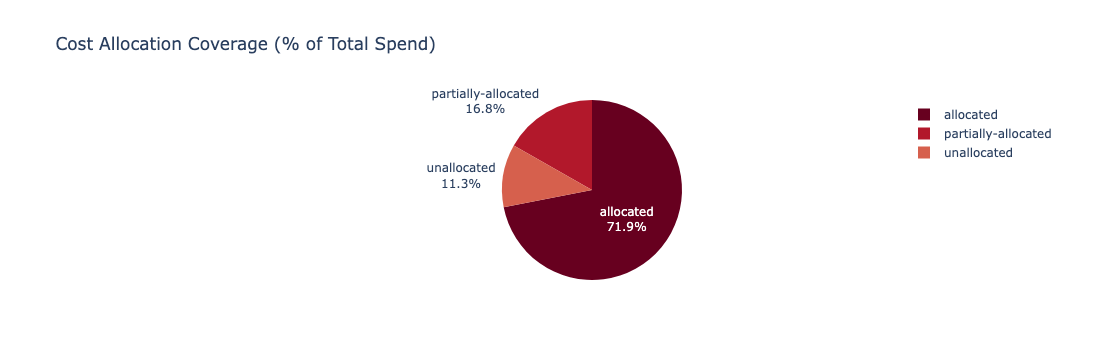

In [56]:
import plotly.express as px

fig = px.pie(
    df_alloc,
    names="allocation_status", values="total_cost",
    title="Cost Allocation Coverage (% of Total Spend)",
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig.update_traces(textinfo="percent+label")
fig.show()

In [57]:
# Tag field completeness
sql = """
SELECT
    ROUND(COUNT(CASE WHEN tag_owner       IS NOT NULL AND tag_owner       != '' THEN 1 END) * 100.0 / COUNT(*), 1) AS tag_owner_pct,
    ROUND(COUNT(CASE WHEN tag_environment IS NOT NULL AND tag_environment != '' THEN 1 END) * 100.0 / COUNT(*), 1) AS tag_environment_pct,
    ROUND(COUNT(CASE WHEN tag_product     IS NOT NULL AND tag_product     != '' THEN 1 END) * 100.0 / COUNT(*), 1) AS tag_product_pct,
    ROUND(COUNT(CASE WHEN tag_cost_center IS NOT NULL AND tag_cost_center != '' THEN 1 END) * 100.0 / COUNT(*), 1) AS tag_cost_center_pct
FROM billing_case01_enriched
"""
df_tags = pd.read_sql(sql, conn)
df_tags.T.rename(columns={0: "coverage_%"})

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/2717280217.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tags = pd.read_sql(sql, conn)


,coverage_%
tag_owner_pct,90.5
tag_environment_pct,98.5
tag_product_pct,92.4
tag_cost_center_pct,93.3


In [58]:
# %% [markdown]
# ## Analysis 11 – Unallocated Spend by Service ("Dark Spend")

# %%
sql = """
SELECT
    service_name,
    allocation_status,
    ROUND(SUM(cost_usd), 2) AS total_cost
FROM billing_case01_enriched
WHERE allocation_status != 'allocated'
GROUP BY service_name, allocation_status
ORDER BY total_cost DESC
"""
df_dark = pd.read_sql(sql, conn)
df_dark

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3020377807.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dark = pd.read_sql(sql, conn)


,service_name,allocation_status,total_cost
0,AWS Fargate,partially-allocated,4737.19
1,Amazon EC2,partially-allocated,4083.74
2,AWS Fargate,unallocated,3532.49
3,Amazon RDS,partially-allocated,3149.74
4,Amazon EC2,unallocated,3097.42
5,Amazon RDS,unallocated,2247.34
6,AWS Lambda,partially-allocated,1573.71
7,NAT Gateway,partially-allocated,1249.80
8,Amazon EBS,partially-allocated,1241.09
9,AWS Lambda,unallocated,1163.46


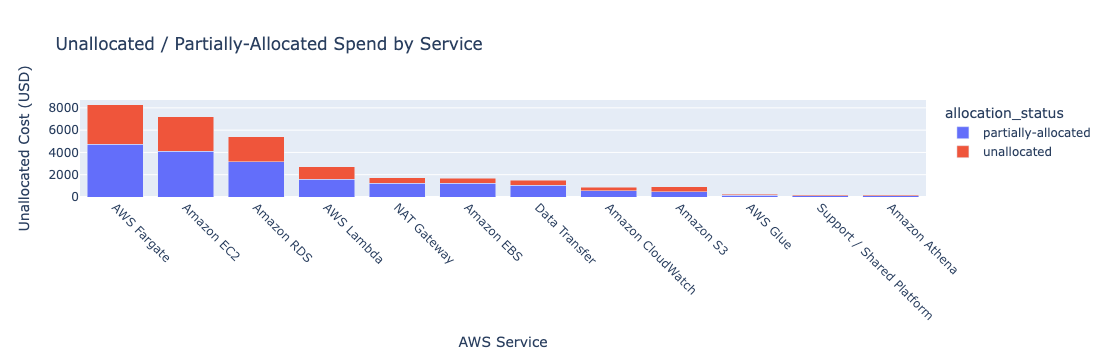

In [59]:
fig = px.bar(
    df_dark,
    x="service_name", y="total_cost",
    color="allocation_status", barmode="stack",
    title="Unallocated / Partially-Allocated Spend by Service",
    labels={"total_cost": "Unallocated Cost (USD)", "service_name": "AWS Service"}
)
fig.update_xaxes(tickangle=45)
fig.show()

In [60]:
# anomoly detection

# %% [markdown]
# ## Analysis 12 – Anomaly Detection & Cost Spike Flagging

# %%
sql = """
WITH stats AS (
    SELECT
        usage_date,
        product_name,
        service_name,
        environment,
        team,
        cost_usd,
        anomaly_flag,
        AVG(cost_usd)         OVER (PARTITION BY product_name) AS avg_cost,
        STDDEV_SAMP(cost_usd) OVER (PARTITION BY product_name) AS std_cost
    FROM billing_case01_enriched
)
SELECT
    usage_date,
    product_name,
    service_name,
    environment,
    team,
    cost_usd,
    anomaly_flag,
    avg_cost,
    std_cost,
    ROUND((cost_usd - avg_cost) / NULLIF(std_cost, 0), 4) AS z_score
FROM stats
WHERE
    ABS((cost_usd - avg_cost) / NULLIF(std_cost, 0)) > 2
    OR anomaly_flag = 1
ORDER BY z_score DESC
"""
df_anomaly = pd.read_sql(sql, conn)
print(f"Anomalies detected: {len(df_anomaly)}")
df_anomaly

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/2250938095.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_anomaly = pd.read_sql(sql, conn)


Anomalies detected: 502


,usage_date,product_name,service_name,environment,team,cost_usd,anomaly_flag,avg_cost,std_cost,z_score
0,2026-01-14,workflow-intelligence,AWS Fargate,prod,ml-engineering,250.61,0,28.758964,39.352720,5.6375
1,2026-01-07,workflow-intelligence,AWS Fargate,prod,data,244.58,0,28.758964,39.352720,5.4843
2,2026-01-11,reporting-api,AWS Fargate,prod,platform,55.87,0,6.496136,9.221095,5.3544
3,2025-12-29,reporting-api,AWS Fargate,prod,platform,54.61,0,6.496136,9.221095,5.2178
4,2026-01-18,workflow-intelligence,Amazon EC2,prod,ml-engineering,232.47,0,28.758964,39.352720,5.1765
...,...,...,...,...,...,...,...,...,...,...
497,2025-12-14,workflow-intelligence,Amazon CloudWatch,dev,data,8.49,1,28.758964,39.352720,-0.5151
498,2025-12-09,ai-assistant,Amazon CloudWatch,dev,data,8.65,1,31.347570,43.686676,-0.5196
499,2025-12-08,reporting-api,Amazon CloudWatch,dev,data,1.64,1,6.496136,9.221095,-0.5266
500,2025-12-04,workflow-intelligence,Data Transfer,dev,product-analytics,7.75,1,28.758964,39.352720,-0.5339


In [61]:
# Built-in flag distribution
sql = """
SELECT
    anomaly_flag,
    COUNT(*) AS count,
    ROUND(SUM(cost_usd), 2) AS flagged_cost
FROM billing_case01_enriched
GROUP BY anomaly_flag
ORDER BY anomaly_flag
"""
df_flags = pd.read_sql(sql, conn)
df_flags

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3858995609.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_flags = pd.read_sql(sql, conn)


,anomaly_flag,count,flagged_cost
0,0,4803,104692.57
1,1,197,5327.83


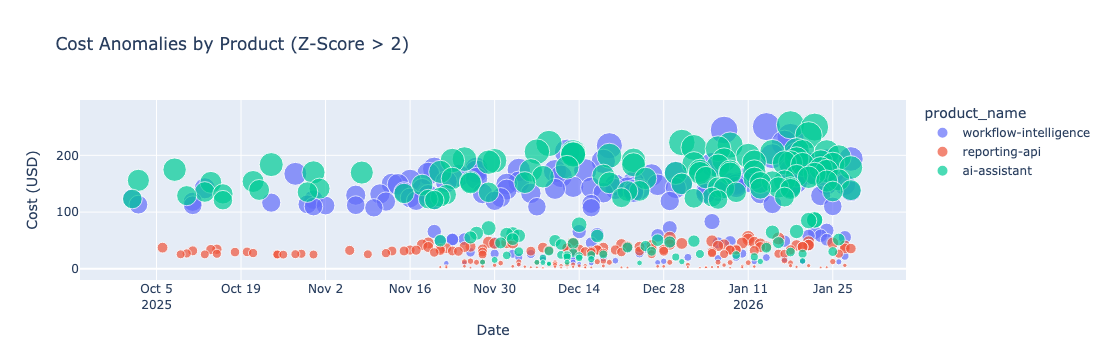

In [62]:
fig = px.scatter(
    df_anomaly,
    x="usage_date", y="cost_usd",
    color="product_name",
    hover_data=["service_name", "z_score", "environment", "team"],
    size="cost_usd", size_max=20,
    title="Cost Anomalies by Product (Z-Score > 2)",
    labels={"cost_usd": "Cost (USD)", "usage_date": "Date"}
)
fig.show()

In [63]:
# %% [markdown]
# ## Analysis 13 – Actual vs. Forecast vs. Budget Variance by Product & Month

# %%
sql = """
SELECT
    billing_period,
    product_name,
    ROUND(SUM(cost_usd), 2)               AS actual_cost,
    ROUND(SUM(forecast_baseline_cost), 2) AS forecast_cost,
    ROUND(SUM(budget_amount), 2)          AS budget_amount,
    ROUND(SUM(cost_usd) - SUM(forecast_baseline_cost), 2) AS actual_vs_forecast,
    ROUND(SUM(cost_usd) - SUM(budget_amount), 2)          AS actual_vs_budget,
    ROUND(
        (SUM(cost_usd) - SUM(budget_amount)) * 100.0
        / NULLIF(SUM(budget_amount), 0), 2
    ) AS budget_variance_pct
FROM billing_case01_enriched
GROUP BY billing_period, product_name
ORDER BY billing_period, actual_cost DESC
"""
df_variance = pd.read_sql(sql, conn)
df_variance

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/691461613.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_variance = pd.read_sql(sql, conn)


,billing_period,product_name,actual_cost,forecast_cost,budget_amount,actual_vs_forecast,actual_vs_budget,budget_variance_pct
0,2025-10,ai-assistant,10583.80,6.801343e+07,6.795821e+07,-6.800284e+07,-6.794762e+07,-99.98
1,2025-10,workflow-intelligence,9236.79,1.028911e+08,1.026247e+08,-1.028819e+08,-1.026155e+08,-99.99
2,2025-10,reporting-api,2183.16,4.439056e+07,4.440758e+07,-4.438837e+07,-4.440540e+07,-100.00
3,2025-11,workflow-intelligence,10720.91,9.369581e+07,9.358484e+07,-9.368509e+07,-9.357412e+07,-99.99
4,2025-11,ai-assistant,10656.39,6.945867e+07,6.922177e+07,-6.944801e+07,-6.921111e+07,-99.98
5,2025-11,reporting-api,2718.75,4.488227e+07,4.486035e+07,-4.487956e+07,-4.485764e+07,-99.99
6,2025-12,workflow-intelligence,12939.69,1.094559e+08,1.091405e+08,-1.094429e+08,-1.091275e+08,-99.99
7,2025-12,ai-assistant,12917.85,6.452769e+07,6.424577e+07,-6.451477e+07,-6.423285e+07,-99.98
8,2025-12,reporting-api,3055.17,4.579570e+07,4.565221e+07,-4.579265e+07,-4.564915e+07,-99.99
9,2026-01,ai-assistant,17314.67,6.971894e+07,6.981515e+07,-6.970163e+07,-6.979783e+07,-99.98


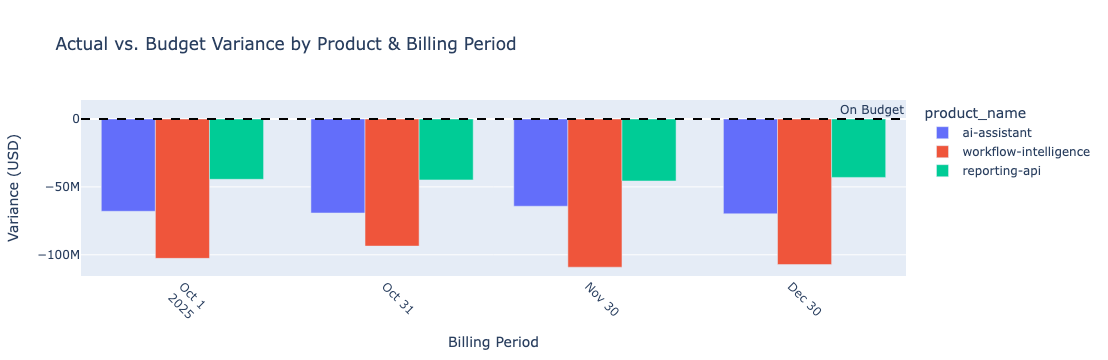

In [64]:
fig = px.bar(
    df_variance,
    x="billing_period", y="actual_vs_budget",
    color="product_name", barmode="group",
    title="Actual vs. Budget Variance by Product & Billing Period",
    labels={"actual_vs_budget": "Variance (USD)", "billing_period": "Billing Period"}
)
fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="On Budget")
fig.update_xaxes(tickangle=45)
fig.show()

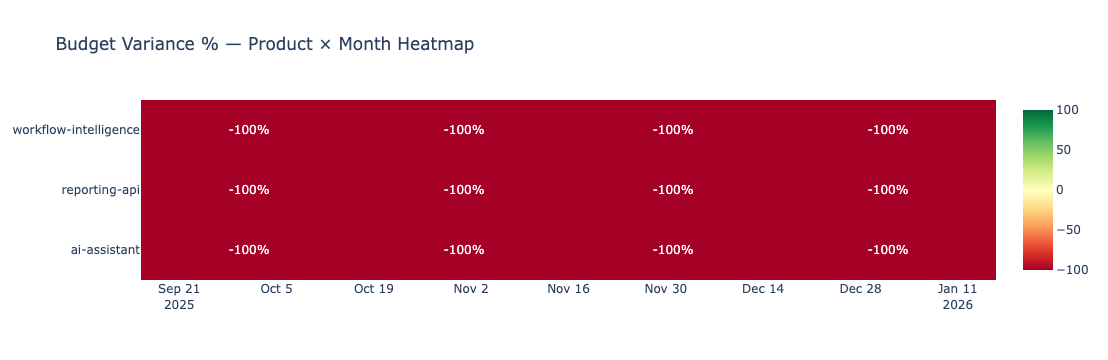

In [65]:
# Heatmap: variance % by product × billing period
df_piv = df_variance.pivot(index="product_name", columns="billing_period", values="budget_variance_pct")

fig2 = go.Figure(data=go.Heatmap(
    z=df_piv.values,
    x=df_piv.columns.tolist(),
    y=df_piv.index.tolist(),
    colorscale="RdYlGn",
    zmid=0,
    text=df_piv.values.round(1),
    texttemplate="%{text}%"
))
fig2.update_layout(title="Budget Variance % — Product × Month Heatmap")
fig2.show()

In [66]:
# %% [markdown]
# ## Analysis 15 – Team-Level Cost Attribution (Chargeback / Showback)

# %%
sql = """
SELECT
    team,
    environment,
    ROUND(SUM(cost_usd), 2) AS total_cost,
    COUNT(DISTINCT product_name) AS num_products
FROM billing_case01_enriched
WHERE team IS NOT NULL AND team != ''
GROUP BY team, environment
ORDER BY total_cost DESC
"""
df_team = pd.read_sql(sql, conn)
df_team

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/963822702.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_team = pd.read_sql(sql, conn)


,team,environment,total_cost,num_products
0,product-analytics,prod,19640.72,3
1,ml-engineering,prod,16877.35,3
2,platform,prod,16499.36,3
3,data,prod,16299.20,3
4,product-analytics,staging,7598.31,3
5,ml-engineering,staging,6910.42,3
6,platform,staging,6605.69,3
7,data,staging,6338.64,3
8,platform,dev,3406.92,3
9,product-analytics,dev,3388.79,3


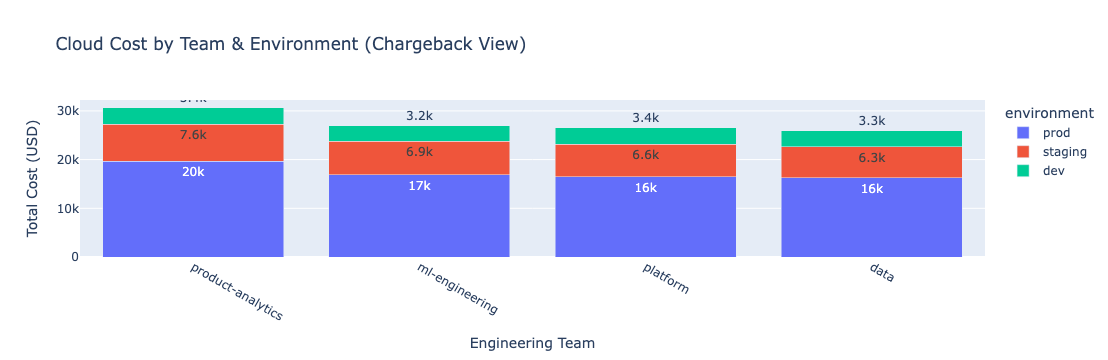

In [67]:
fig = px.bar(
    df_team,
    x="team", y="total_cost",
    color="environment", barmode="stack",
    title="Cloud Cost by Team & Environment (Chargeback View)",
    labels={"total_cost": "Total Cost (USD)", "team": "Engineering Team"},
    text_auto=".2s"
)
fig.update_xaxes(tickangle=30)
fig.show()

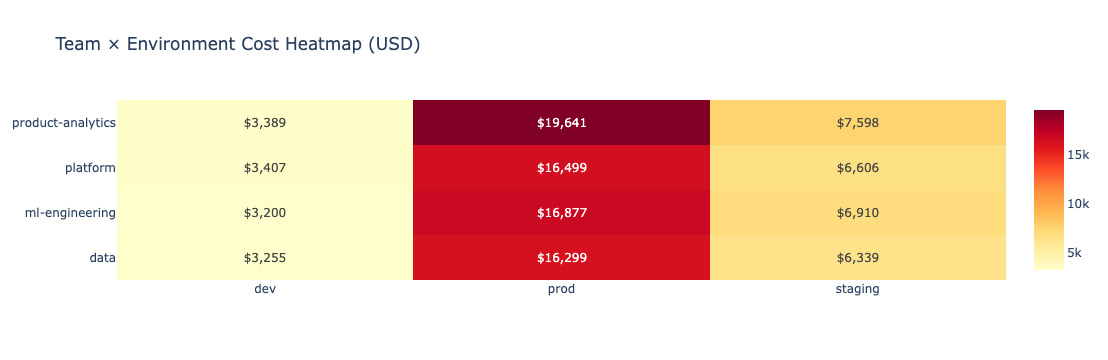

In [68]:
df_team_piv = df_team.pivot(index="team", columns="environment", values="total_cost").fillna(0)

fig2 = go.Figure(data=go.Heatmap(
    z=df_team_piv.values,
    x=df_team_piv.columns.tolist(),
    y=df_team_piv.index.tolist(),
    colorscale="YlOrRd",
    text=df_team_piv.values.round(0),
    texttemplate="$%{text:,.0f}"
))
fig2.update_layout(title="Team × Environment Cost Heatmap (USD)")
fig2.show()

In [69]:
# %% [markdown]
# ## Analysis 17 – SLA Tier × Product Cost Efficiency

# %%
sql = """
SELECT
    sla_tier,
    product_name,
    enterprise_customer_flag,
    ROUND(SUM(cost_usd), 2)              AS total_cloud_cost,
    ROUND(SUM(monthly_revenue_proxy), 2) AS total_revenue,
    SUM(workflows_processed)             AS total_workflows,
    ROUND(SUM(monthly_revenue_proxy) - SUM(cost_usd), 2) AS gross_margin,
    ROUND(
        (SUM(monthly_revenue_proxy) - SUM(cost_usd))
        / NULLIF(SUM(workflows_processed), 0), 4
    ) AS margin_per_workflow,
    ROUND(SUM(cost_usd) / NULLIF(SUM(workflows_processed), 0), 4) AS cost_per_workflow
FROM billing_case01_enriched
GROUP BY sla_tier, product_name, enterprise_customer_flag
ORDER BY sla_tier, margin_per_workflow DESC
"""
df_sla = pd.read_sql(sql, conn)
df_sla

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/2863762220.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sla = pd.read_sql(sql, conn)


,sla_tier,product_name,enterprise_customer_flag,total_cloud_cost,total_revenue,total_workflows,gross_margin,margin_per_workflow,cost_per_workflow
0,enterprise,reporting-api,1,2054.07,2.802245e+08,4232486,2.802225e+08,66.2075,0.0005
1,enterprise,workflow-intelligence,1,10492.42,6.882306e+08,18953310,6.882201e+08,36.3113,0.0006
2,enterprise,ai-assistant,1,8845.96,4.046235e+08,18740894,4.046147e+08,21.5899,0.0005
3,premium,reporting-api,1,1144.22,1.604627e+08,2488553,1.604616e+08,64.4799,0.0005
4,premium,reporting-api,0,2173.83,2.634015e+08,4128595,2.633993e+08,63.7988,0.0005
5,premium,workflow-intelligence,1,4963.02,3.414303e+08,9014188,3.414254e+08,37.8764,0.0006
6,premium,workflow-intelligence,0,13259.87,8.985219e+08,26474003,8.985086e+08,33.9393,0.0005
7,premium,ai-assistant,0,15224.25,5.832131e+08,27044432,5.831979e+08,21.5644,0.0006
8,premium,ai-assistant,1,6097.53,2.636134e+08,12622354,2.636073e+08,20.8842,0.0005
9,standard,reporting-api,0,5723.28,7.167740e+08,11135894,7.167683e+08,64.3656,0.0005


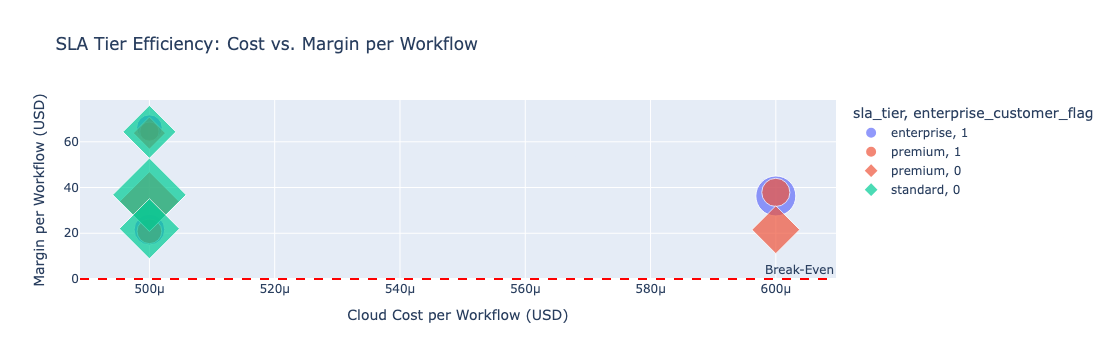

In [70]:
fig = px.scatter(
    df_sla,
    x="cost_per_workflow", y="margin_per_workflow",
    color="sla_tier",
    symbol="enterprise_customer_flag",
    size="total_revenue", size_max=40,
    hover_name="product_name",
    title="SLA Tier Efficiency: Cost vs. Margin per Workflow",
    labels={
        "cost_per_workflow": "Cloud Cost per Workflow (USD)",
        "margin_per_workflow": "Margin per Workflow (USD)"
    }
)
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Break-Even")
fig.show()

In [71]:
# %% [markdown]
# ## Analysis 18 – Acquisition Phase Cost Segmentation

# %%
sql = """
SELECT
    acquisition_phase,
    product_name,
    ROUND(SUM(cost_usd), 2)              AS total_cost,
    ROUND(SUM(monthly_revenue_proxy), 2) AS total_revenue,
    SUM(workflows_processed)             AS total_workflows,
    ROUND(SUM(monthly_revenue_proxy) - SUM(cost_usd), 2) AS gross_margin,
    ROUND(SUM(cost_usd) / NULLIF(SUM(workflows_processed), 0), 4) AS cost_per_workflow,
    ROUND(
        SUM(cost_usd) * 100.0 / NULLIF(SUM(monthly_revenue_proxy), 0), 2
    ) AS cloud_cost_pct_revenue
FROM billing_case01_enriched
GROUP BY acquisition_phase, product_name
ORDER BY acquisition_phase, total_cost DESC
"""
df_phase = pd.read_sql(sql, conn)
df_phase

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3358717186.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_phase = pd.read_sql(sql, conn)


,acquisition_phase,product_name,total_cost,total_revenue,total_workflows,gross_margin,cost_per_workflow,cloud_cost_pct_revenue
0,integration,workflow-intelligence,19676.44,1.282731e+09,33894750,1.282711e+09,0.0006,0.0
1,integration,ai-assistant,19422.63,8.009015e+08,35175915,8.008820e+08,0.0006,0.0
2,integration,reporting-api,4674.59,5.538346e+08,8291704,5.538299e+08,0.0006,0.0
3,post-integration,ai-assistant,17314.67,5.682807e+08,27918903,5.682634e+08,0.0006,0.0
4,post-integration,workflow-intelligence,14554.90,8.654816e+08,25875733,8.654670e+08,0.0006,0.0
5,post-integration,reporting-api,3138.32,3.441300e+08,5451020,3.441268e+08,0.0006,0.0
6,pre-integration,ai-assistant,14735.41,8.040741e+08,37241004,8.040593e+08,0.0004,0.0
7,pre-integration,workflow-intelligence,13220.95,1.155357e+09,32025331,1.155344e+09,0.0004,0.0
8,pre-integration,reporting-api,3282.49,5.228982e+08,8242804,5.228949e+08,0.0004,0.0


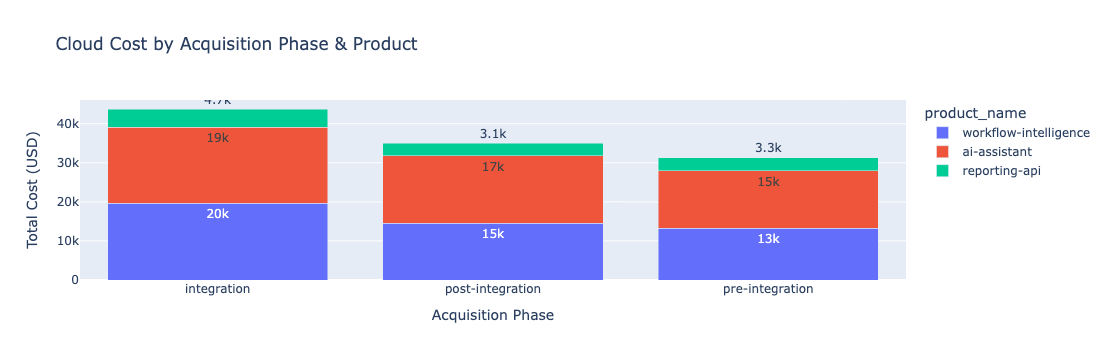

In [72]:
fig = px.bar(
    df_phase,
    x="acquisition_phase", y="total_cost",
    color="product_name", barmode="stack",
    title="Cloud Cost by Acquisition Phase & Product",
    labels={"total_cost": "Total Cost (USD)", "acquisition_phase": "Acquisition Phase"},
    text_auto=".2s"
)
fig.show()

In [73]:
# %% [markdown]
# ## Deep Dive – AWS Fargate: Allocation, Anomaly & Team Attribution

# %%
sql = """
WITH fargate_stats AS (
    SELECT
        product_name,
        team,
        environment,
        allocation_status,
        anomaly_flag,
        cost_usd,
        AVG(cost_usd)         OVER (PARTITION BY product_name) AS avg_cost,
        STDDEV_SAMP(cost_usd) OVER (PARTITION BY product_name) AS std_cost
    FROM billing_case01_enriched
    WHERE service_name = 'AWS Fargate'
)
SELECT
    product_name,
    team,
    environment,
    allocation_status,
    anomaly_flag,
    ROUND(SUM(cost_usd), 2) AS total_cost,
    COUNT(*) AS row_count,
    ROUND(
        (SUM(cost_usd) - AVG(avg_cost)) / NULLIF(AVG(std_cost), 0), 4
    ) AS z_score
FROM fargate_stats
GROUP BY product_name, team, environment, allocation_status, anomaly_flag
ORDER BY total_cost DESC
"""
df_fargate = pd.read_sql(sql, conn)
df_fargate

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3808968818.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fargate = pd.read_sql(sql, conn)


,product_name,team,environment,allocation_status,anomaly_flag,total_cost,row_count,z_score
0,workflow-intelligence,data,prod,allocated,0,2014.57,14,34.7857
1,ai-assistant,product-analytics,prod,allocated,0,1938.17,12,29.4273
2,workflow-intelligence,ml-engineering,prod,allocated,0,1556.79,9,26.5139
3,ai-assistant,platform,prod,allocated,0,1453.25,9,21.6624
4,workflow-intelligence,product-analytics,prod,allocated,0,1405.51,10,23.7804
...,...,...,...,...,...,...,...,...
92,reporting-api,platform,staging,unallocated,0,9.25,1,-0.9551
93,reporting-api,data,dev,partially-allocated,0,8.10,1,-1.0382
94,reporting-api,ml-engineering,dev,unallocated,0,7.28,1,-1.0974
95,reporting-api,platform,dev,unallocated,0,5.47,1,-1.2282


In [74]:
# Fargate dark spend breakdown: which team/product combos are unallocated?
sql = """
SELECT
    product_name,
    team,
    allocation_status,
    ROUND(SUM(cost_usd), 2) AS total_cost
FROM billing_case01_enriched
WHERE service_name = 'AWS Fargate'
  AND allocation_status != 'allocated'
GROUP BY product_name, team, allocation_status
ORDER BY total_cost DESC
"""
df_fargate_dark = pd.read_sql(sql, conn)
df_fargate_dark

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/4077353956.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fargate_dark = pd.read_sql(sql, conn)


,product_name,team,allocation_status,total_cost
0,ai-assistant,platform,partially-allocated,1120.21
1,ai-assistant,product-analytics,unallocated,933.13
2,workflow-intelligence,product-analytics,partially-allocated,772.31
3,ai-assistant,product-analytics,partially-allocated,676.76
4,workflow-intelligence,ml-engineering,partially-allocated,496.25
5,workflow-intelligence,ml-engineering,unallocated,422.21
6,ai-assistant,ml-engineering,unallocated,376.65
7,workflow-intelligence,data,partially-allocated,362.29
8,workflow-intelligence,platform,partially-allocated,360.45
9,ai-assistant,platform,unallocated,357.16


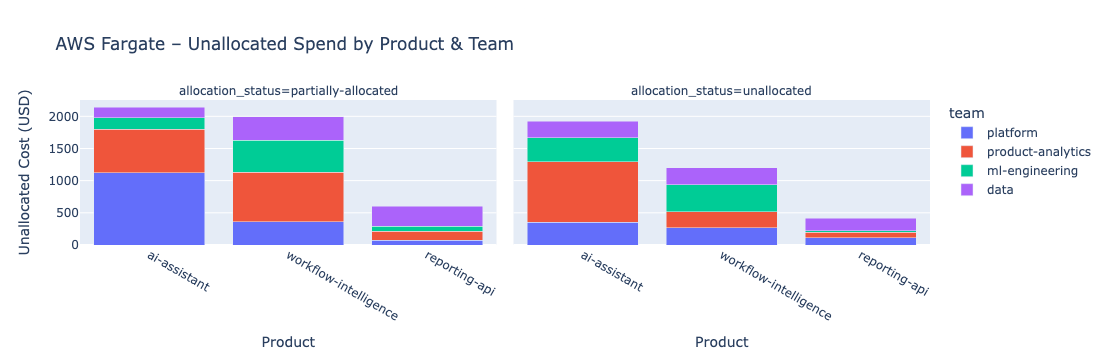

In [75]:
fig = px.bar(
    df_fargate_dark,
    x="product_name", y="total_cost",
    color="team", barmode="stack",
    facet_col="allocation_status",
    title="AWS Fargate – Unallocated Spend by Product & Team",
    labels={"total_cost": "Unallocated Cost (USD)", "product_name": "Product"}
)
fig.update_xaxes(tickangle=30)
fig.show()

In [76]:
# EC2

# %% [markdown]
# ## Deep Dive – Amazon EC2: Allocation & Anomaly by Team

# %%
sql = """
WITH ec2_stats AS (
    SELECT
        product_name,
        team,
        environment,
        allocation_status,
        anomaly_flag,
        cost_usd,
        AVG(cost_usd)         OVER (PARTITION BY product_name) AS avg_cost,
        STDDEV_SAMP(cost_usd) OVER (PARTITION BY product_name) AS std_cost
    FROM billing_case01_enriched
    WHERE service_name = 'Amazon EC2'
)
SELECT
    product_name,
    team,
    environment,
    allocation_status,
    anomaly_flag,
    ROUND(SUM(cost_usd), 2) AS total_cost,
    COUNT(*) AS row_count,
    ROUND(
        (SUM(cost_usd) - AVG(avg_cost)) / NULLIF(AVG(std_cost), 0), 4
    ) AS z_score
FROM ec2_stats
GROUP BY product_name, team, environment, allocation_status, anomaly_flag
ORDER BY total_cost DESC
"""
df_ec2 = pd.read_sql(sql, conn)
df_ec2

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/1715088359.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ec2 = pd.read_sql(sql, conn)


,product_name,team,environment,allocation_status,anomaly_flag,total_cost,row_count,z_score
0,workflow-intelligence,ml-engineering,prod,allocated,0,2061.21,16,42.4500
1,workflow-intelligence,platform,prod,allocated,0,1807.00,14,36.9956
2,ai-assistant,product-analytics,prod,allocated,0,1500.42,11,26.0245
3,workflow-intelligence,product-analytics,prod,allocated,0,1491.88,12,30.2344
4,workflow-intelligence,data,prod,allocated,0,1448.68,11,29.3075
...,...,...,...,...,...,...,...,...
92,reporting-api,product-analytics,dev,partially-allocated,0,10.49,2,-0.7712
93,reporting-api,ml-engineering,dev,unallocated,0,10.08,1,-0.8078
94,reporting-api,platform,dev,partially-allocated,0,8.74,1,-0.9276
95,reporting-api,product-analytics,dev,unallocated,0,7.87,1,-1.0054


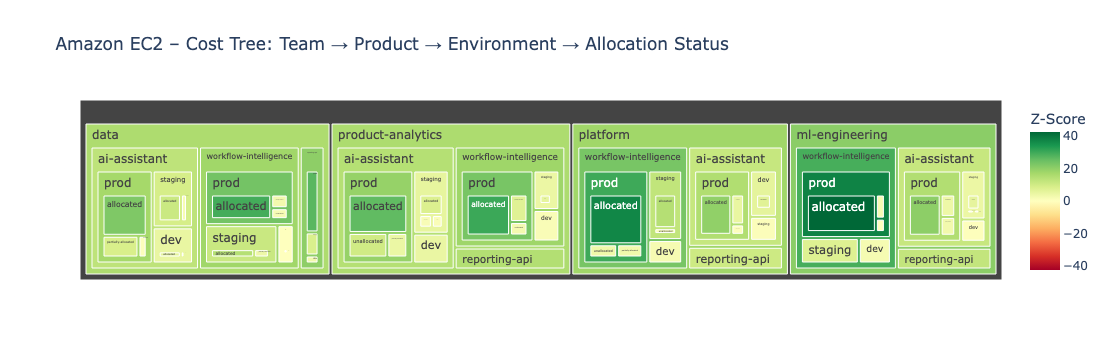

In [77]:
fig = px.treemap(
    df_ec2,
    path=["team", "product_name", "environment", "allocation_status"],
    values="total_cost",
    color="z_score",
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
    title="Amazon EC2 – Cost Tree: Team → Product → Environment → Allocation Status",
    labels={"total_cost": "Cost (USD)", "z_score": "Z-Score"}
)
fig.show()

In [78]:
# %% [markdown]
# ## Cross-Service – Cost Rows That Are BOTH Anomalous AND Unallocated
# These are your highest-priority governance findings:
# spend that spiked AND has no owner.

# %%
sql = """
WITH stats AS (
    SELECT
        usage_date,
        service_name,
        product_name,
        team,
        environment,
        allocation_status,
        anomaly_flag,
        cost_usd,
        AVG(cost_usd)         OVER (PARTITION BY product_name, service_name) AS avg_cost,
        STDDEV_SAMP(cost_usd) OVER (PARTITION BY product_name, service_name) AS std_cost
    FROM billing_case01_enriched
)
SELECT
    usage_date,
    service_name,
    product_name,
    team,
    environment,
    allocation_status,
    anomaly_flag,
    cost_usd,
    ROUND((cost_usd - avg_cost) / NULLIF(std_cost, 0), 4) AS z_score
FROM stats
WHERE
    allocation_status != 'allocated'
    AND (
        ABS((cost_usd - avg_cost) / NULLIF(std_cost, 0)) > 2
        OR anomaly_flag = 1
    )
ORDER BY cost_usd DESC
"""
df_worst = pd.read_sql(sql, conn)
print(f"High-priority findings (anomalous + unallocated): {len(df_worst)} rows")
df_worst

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/1579167559.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_worst = pd.read_sql(sql, conn)


High-priority findings (anomalous + unallocated): 100 rows


,usage_date,service_name,product_name,team,environment,allocation_status,anomaly_flag,cost_usd,z_score
0,2026-01-18,AWS Fargate,ai-assistant,platform,prod,partially-allocated,0,253.78,2.4554
1,2025-12-19,AWS Fargate,workflow-intelligence,product-analytics,prod,partially-allocated,0,216.95,2.3039
2,2026-01-02,Amazon EC2,ai-assistant,product-analytics,prod,unallocated,0,213.83,2.3321
3,2025-12-12,AWS Fargate,workflow-intelligence,data,prod,partially-allocated,0,206.16,2.1089
4,2026-01-28,Amazon RDS,ai-assistant,product-analytics,prod,partially-allocated,0,178.52,2.4164
...,...,...,...,...,...,...,...,...,...
95,2026-01-22,Support / Shared Platform,reporting-api,data,prod,partially-allocated,0,0.87,2.4652
96,2025-12-20,Support / Shared Platform,reporting-api,platform,prod,unallocated,0,0.85,2.3813
97,2025-12-07,Support / Shared Platform,reporting-api,data,prod,partially-allocated,0,0.84,2.3393
98,2025-12-26,Support / Shared Platform,reporting-api,product-analytics,prod,partially-allocated,0,0.80,2.1715


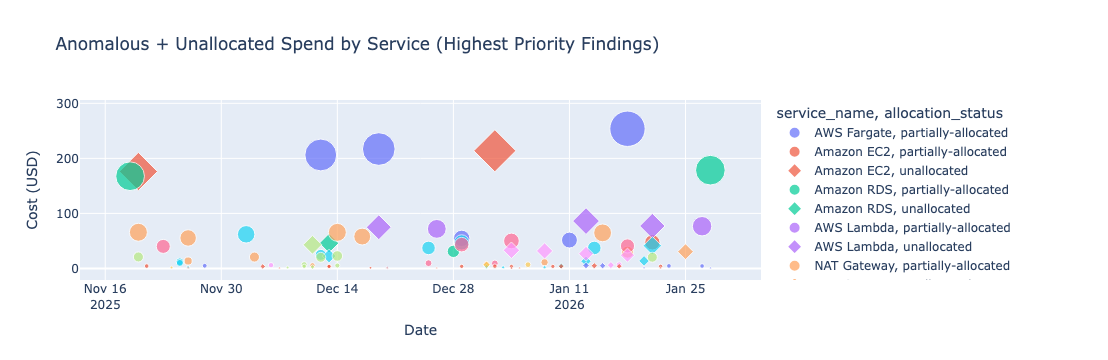

In [79]:
fig = px.scatter(
    df_worst,
    x="usage_date", y="cost_usd",
    color="service_name",
    size="cost_usd", size_max=25,
    symbol="allocation_status",
    hover_data=["product_name", "team", "environment", "z_score"],
    title="Anomalous + Unallocated Spend by Service (Highest Priority Findings)",
    labels={"cost_usd": "Cost (USD)", "usage_date": "Date"}
)
fig.show()

In [80]:
# %% [markdown]
# ## Governance Scorecard – Team Level
# Composite score (0–100) across allocation, tagging, anomaly, and budget discipline.
# 100 = perfect governance. Below 70 = intervention required.

# %%
sql = """
WITH base AS (
    SELECT
        team,
        cost_usd,
        allocation_status,
        anomaly_flag,
        tag_owner,
        tag_environment,
        tag_product,
        tag_cost_center,
        budget_amount,
        forecast_baseline_cost,
        ABS(cost_usd - forecast_baseline_cost) / NULLIF(forecast_baseline_cost, 0) AS forecast_variance_pct
    FROM billing_case01_enriched
    WHERE team IS NOT NULL AND team != ''
),
scored AS (
    SELECT
        team,

        -- Allocation score: % fully allocated (0-100)
        ROUND(
            COUNT(CASE WHEN allocation_status = 'allocated' THEN 1 END) * 100.0 / COUNT(*), 1
        ) AS allocation_score,

        -- Tagging score: % of rows with all 4 tags present (0-100)
        ROUND(
            COUNT(CASE WHEN
                tag_owner IS NOT NULL AND tag_owner != '' AND
                tag_environment IS NOT NULL AND tag_environment != '' AND
                tag_product IS NOT NULL AND tag_product != '' AND
                tag_cost_center IS NOT NULL AND tag_cost_center != ''
            THEN 1 END) * 100.0 / COUNT(*), 1
        ) AS tagging_score,

        -- Anomaly score: inverse of anomaly rate (100 = no anomalies)
        ROUND(
            100 - (COUNT(CASE WHEN anomaly_flag = 1 THEN 1 END) * 100.0 / COUNT(*)), 1
        ) AS anomaly_score,

        -- Budget discipline score: inverse of avg forecast variance (capped at 100)
        ROUND(
            GREATEST(0, 100 - AVG(forecast_variance_pct) * 100), 1
        ) AS budget_score,

        ROUND(SUM(cost_usd), 2) AS total_cost
    FROM base
    GROUP BY team
)
SELECT
    team,
    allocation_score,
    tagging_score,
    anomaly_score,
    budget_score,
    total_cost,
    ROUND(
        (allocation_score * 0.30) +
        (tagging_score   * 0.25) +
        (anomaly_score   * 0.25) +
        (budget_score    * 0.20), 1
    ) AS governance_score
FROM scored
ORDER BY governance_score DESC
"""
df_gov_team = pd.read_sql(sql, conn)
df_gov_team

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/1660145951.py:73: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gov_team = pd.read_sql(sql, conn)


,team,allocation_score,tagging_score,anomaly_score,budget_score,total_cost,governance_score
0,data,71.3,77.8,96.3,0.0,25892.62,64.9
1,platform,70.0,78.7,95.5,0.0,26511.97,64.6
2,product-analytics,67.6,76.7,96.8,0.0,30627.82,63.7
3,ml-engineering,70.1,74.4,95.7,0.0,26987.99,63.6


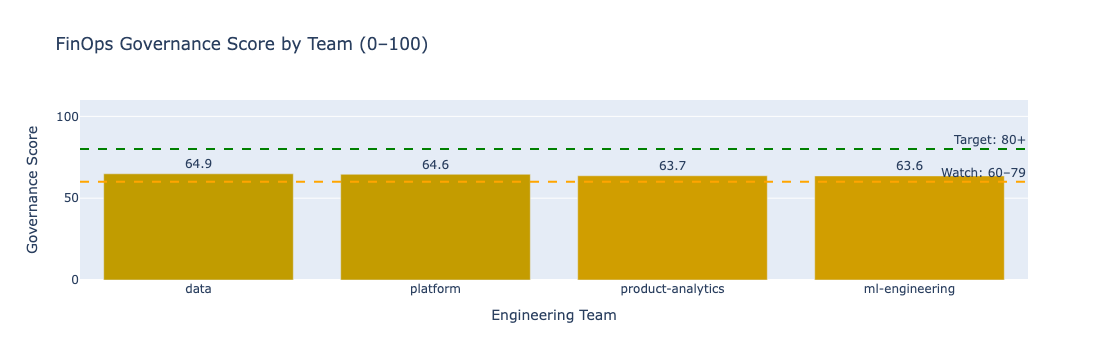

In [81]:
import plotly.express as px
import plotly.graph_objects as go

# Color by score band
def score_color(score):
    if score >= 80: return "green"
    elif score >= 60: return "orange"
    else: return "red"

df_gov_team["color"] = df_gov_team["governance_score"].apply(score_color)

fig = px.bar(
    df_gov_team,
    x="team", y="governance_score",
    color="governance_score",
    color_continuous_scale=[(0,"red"),(0.6,"orange"),(0.8,"green"),(1,"green")],
    range_color=[0, 100],
    text="governance_score",
    title="FinOps Governance Score by Team (0–100)",
    labels={"governance_score": "Governance Score", "team": "Engineering Team"}
)
fig.add_hline(y=80, line_dash="dash", line_color="green", annotation_text="Target: 80+")
fig.add_hline(y=60, line_dash="dash", line_color="orange", annotation_text="Watch: 60–79")
fig.update_traces(textposition="outside")
fig.update_layout(coloraxis_showscale=False, yaxis_range=[0, 110])
fig.show()

In [82]:
# %% [markdown]
# ## Governance Scorecard – Product Level

# %%
sql = """
WITH base AS (
    SELECT
        product_name,
        cost_usd,
        allocation_status,
        anomaly_flag,
        tag_owner,
        tag_environment,
        tag_product,
        tag_cost_center,
        budget_amount,
        forecast_baseline_cost,
        ABS(cost_usd - forecast_baseline_cost) / NULLIF(forecast_baseline_cost, 0) AS forecast_variance_pct
    FROM billing_case01_enriched
    WHERE product_name IS NOT NULL
),
scored AS (
    SELECT
        product_name,
        ROUND(COUNT(CASE WHEN allocation_status = 'allocated' THEN 1 END) * 100.0 / COUNT(*), 1) AS allocation_score,
        ROUND(COUNT(CASE WHEN
            tag_owner IS NOT NULL AND tag_owner != '' AND
            tag_environment IS NOT NULL AND tag_environment != '' AND
            tag_product IS NOT NULL AND tag_product != '' AND
            tag_cost_center IS NOT NULL AND tag_cost_center != ''
        THEN 1 END) * 100.0 / COUNT(*), 1) AS tagging_score,
        ROUND(100 - (COUNT(CASE WHEN anomaly_flag = 1 THEN 1 END) * 100.0 / COUNT(*)), 1) AS anomaly_score,
        ROUND(GREATEST(0, 100 - AVG(forecast_variance_pct) * 100), 1) AS budget_score,
        ROUND(SUM(cost_usd), 2) AS total_cost
    FROM base
    GROUP BY product_name
)
SELECT
    product_name,
    allocation_score,
    tagging_score,
    anomaly_score,
    budget_score,
    total_cost,
    ROUND(
        (allocation_score * 0.30) +
        (tagging_score   * 0.25) +
        (anomaly_score   * 0.25) +
        (budget_score    * 0.20), 1
    ) AS governance_score
FROM scored
ORDER BY governance_score DESC
"""
df_gov_product = pd.read_sql(sql, conn)
df_gov_product

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/3361980316.py:54: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gov_product = pd.read_sql(sql, conn)


,product_name,allocation_score,tagging_score,anomaly_score,budget_score,total_cost,governance_score
0,workflow-intelligence,70.7,78.6,96.3,0.0,47452.29,64.9
1,reporting-api,70.1,76.6,95.7,0.0,11095.40,64.1
2,ai-assistant,68.3,75.4,96.2,0.0,51472.71,63.4


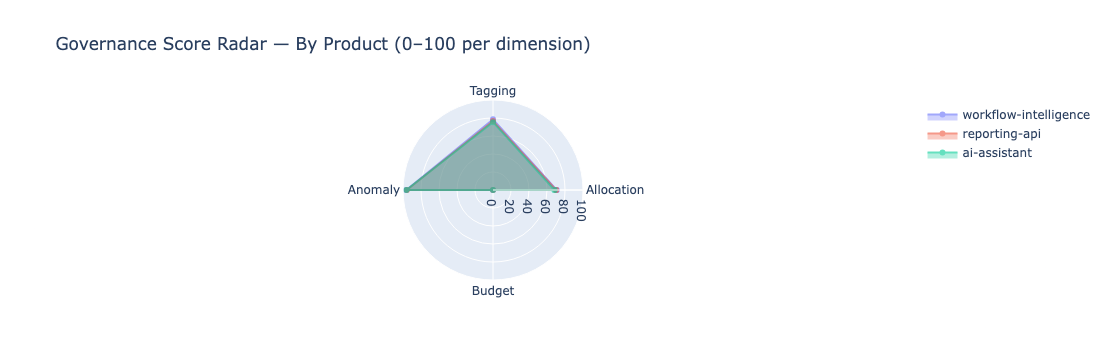

In [83]:
# Radar chart — shows each product's dimension breakdown
categories = ["allocation_score", "tagging_score", "anomaly_score", "budget_score"]
labels = ["Allocation", "Tagging", "Anomaly", "Budget"]

fig = go.Figure()
for _, row in df_gov_product.iterrows():
    values = [row[c] for c in categories]
    values += [values[0]]  # close the loop
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=labels + [labels[0]],
        fill='toself',
        name=row["product_name"],
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title="Governance Score Radar — By Product (0–100 per dimension)",
    showlegend=True
)
fig.show()

In [84]:
# %% [markdown]
# ## Governance Scorecard – Service Level
# Identifies which AWS services are highest-risk from a governance standpoint.

# %%
sql = """
WITH base AS (
    SELECT
        service_name,
        cost_usd,
        allocation_status,
        anomaly_flag,
        tag_owner, tag_environment, tag_product, tag_cost_center,
        forecast_baseline_cost,
        ABS(cost_usd - forecast_baseline_cost) / NULLIF(forecast_baseline_cost, 0) AS forecast_variance_pct
    FROM billing_case01_enriched
),
scored AS (
    SELECT
        service_name,
        ROUND(COUNT(CASE WHEN allocation_status = 'allocated' THEN 1 END) * 100.0 / COUNT(*), 1) AS allocation_score,
        ROUND(COUNT(CASE WHEN
            tag_owner IS NOT NULL AND tag_owner != '' AND
            tag_environment IS NOT NULL AND tag_environment != '' AND
            tag_product IS NOT NULL AND tag_product != '' AND
            tag_cost_center IS NOT NULL AND tag_cost_center != ''
        THEN 1 END) * 100.0 / COUNT(*), 1) AS tagging_score,
        ROUND(100 - (COUNT(CASE WHEN anomaly_flag = 1 THEN 1 END) * 100.0 / COUNT(*)), 1) AS anomaly_score,
        ROUND(GREATEST(0, 100 - AVG(forecast_variance_pct) * 100), 1) AS budget_score,
        ROUND(SUM(cost_usd), 2) AS total_cost
    FROM base
    GROUP BY service_name
)
SELECT
    service_name,
    allocation_score,
    tagging_score,
    anomaly_score,
    budget_score,
    total_cost,
    ROUND(
        (allocation_score * 0.30) +
        (tagging_score   * 0.25) +
        (anomaly_score   * 0.25) +
        (budget_score    * 0.20), 1
    ) AS governance_score
FROM scored
ORDER BY governance_score ASC  -- worst first
"""
df_gov_service = pd.read_sql(sql, conn)
df_gov_service

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/2509725328.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gov_service = pd.read_sql(sql, conn)


,service_name,allocation_score,tagging_score,anomaly_score,budget_score,total_cost,governance_score
0,NAT Gateway,68.4,75.6,81.9,0.0,6218.00,59.9
1,Data Transfer,70.4,80.7,80.7,0.0,5382.88,61.5
2,Amazon CloudWatch,68.7,77.6,92.3,0.0,2754.06,63.1
3,Support / Shared Platform,67.2,75.7,100.0,0.0,411.78,64.1
4,AWS Lambda,68.4,75.2,100.0,0.0,8907.14,64.3
5,Amazon EBS,68.7,74.7,100.0,0.0,5745.86,64.3
6,AWS Glue,68.9,77.0,100.0,0.0,821.36,64.9
7,Amazon Athena,69.4,76.5,100.0,0.0,574.18,64.9
8,AWS Fargate,70.0,75.9,100.0,0.0,28301.39,65.0
9,Amazon S3,71.7,75.7,100.0,0.0,3448.15,65.4


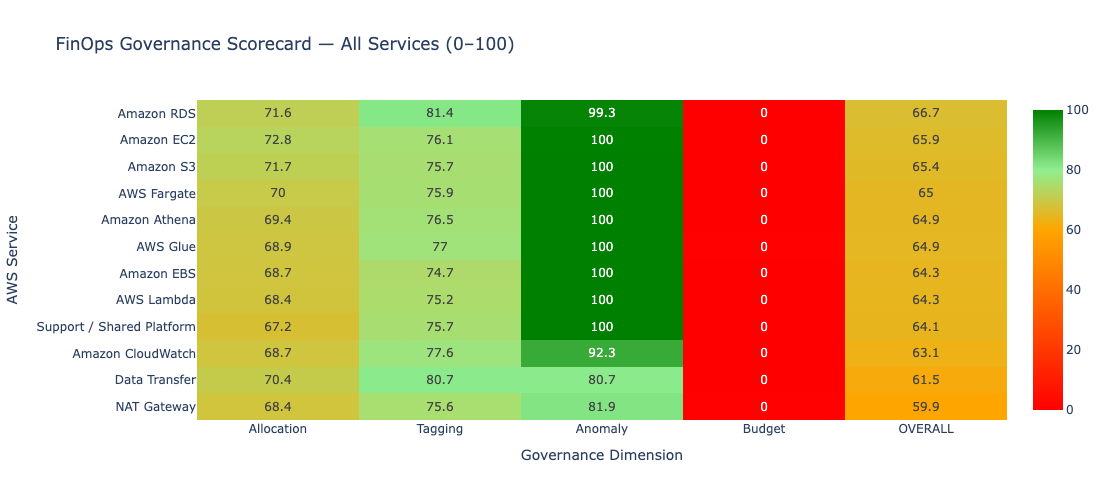

In [85]:
# Heatmap: all dimensions × all services — the full scorecard view
import plotly.graph_objects as go

score_cols = ["allocation_score", "tagging_score", "anomaly_score", "budget_score", "governance_score"]
col_labels = ["Allocation", "Tagging", "Anomaly", "Budget", "OVERALL"]

fig = go.Figure(data=go.Heatmap(
    z=df_gov_service[score_cols].values,
    x=col_labels,
    y=df_gov_service["service_name"].tolist(),
    colorscale=[
        [0.0, "red"],
        [0.6, "orange"],
        [0.8, "lightgreen"],
        [1.0, "green"]
    ],
    zmin=0, zmax=100,
    text=df_gov_service[score_cols].values.round(1),
    texttemplate="%{text}",
))
fig.update_layout(
    title="FinOps Governance Scorecard — All Services (0–100)",
    xaxis_title="Governance Dimension",
    yaxis_title="AWS Service",
    height=500
)
fig.show()

In [87]:
# %% [markdown]
# ## Waste Analysis 1 – Non-Production Spend
# Dev and staging environments should not carry prod-level costs.
# Any dev/staging spend approaching prod levels = likely waste.

# %%
sql = """
WITH env_cost AS (
    SELECT
        environment,
        product_name,
        team,
        ROUND(SUM(cost_usd), 2) AS total_cost,
        COUNT(DISTINCT usage_date) AS active_days
    FROM billing_case01_enriched
    GROUP BY environment, product_name, team
),
prod_baseline AS (
    SELECT product_name, total_cost AS prod_cost
    FROM env_cost
    WHERE environment = 'prod'
)
SELECT
    e.environment,
    e.product_name,
    e.team,
    e.total_cost,
    e.active_days,
    p.prod_cost,
    ROUND(e.total_cost * 100.0 / NULLIF(p.prod_cost, 0), 1) AS pct_of_prod_cost,
    CASE
        WHEN e.environment != 'prod'
         AND e.total_cost * 100.0 / NULLIF(p.prod_cost, 0) > 40
        THEN 'HIGH WASTE RISK'
        WHEN e.environment != 'prod'
         AND e.total_cost * 100.0 / NULLIF(p.prod_cost, 0) > 20
        THEN 'MODERATE WASTE RISK'
        ELSE 'OK'
    END AS waste_flag
FROM env_cost e
LEFT JOIN prod_baseline p ON e.product_name = p.product_name
WHERE e.environment != 'prod'
ORDER BY pct_of_prod_cost DESC
"""
df_nonprod = pd.read_sql(sql, conn)
df_nonprod

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/1785333275.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_nonprod = pd.read_sql(sql, conn)


,environment,product_name,team,total_cost,active_days,prod_cost,pct_of_prod_cost,waste_flag
0,staging,ai-assistant,product-analytics,4153.25,85,7079.32,58.7,HIGH WASTE RISK
1,staging,ai-assistant,product-analytics,4153.25,85,7544.97,55.0,HIGH WASTE RISK
2,staging,ai-assistant,product-analytics,4153.25,85,7763.20,53.5,HIGH WASTE RISK
3,staging,reporting-api,data,787.35,88,1562.77,50.4,HIGH WASTE RISK
4,staging,reporting-api,product-analytics,778.37,84,1562.77,49.8,HIGH WASTE RISK
...,...,...,...,...,...,...,...,...
91,dev,workflow-intelligence,ml-engineering,1232.78,79,8370.99,14.7,OK
92,dev,ai-assistant,product-analytics,1396.67,81,9602.78,14.5,OK
93,dev,reporting-api,data,291.58,73,2027.86,14.4,OK
94,dev,reporting-api,product-analytics,273.08,72,1941.64,14.1,OK


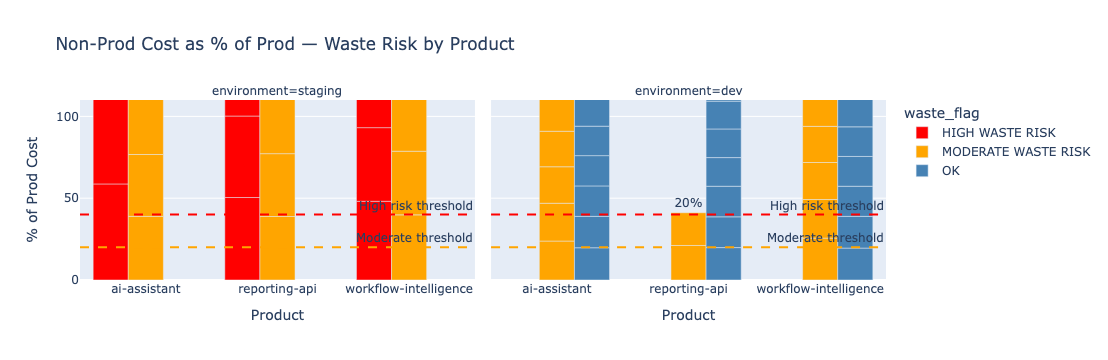

In [88]:
fig = px.bar(
    df_nonprod,
    x="product_name", y="pct_of_prod_cost",
    color="waste_flag",
    facet_col="environment",
    barmode="group",
    text="pct_of_prod_cost",
    title="Non-Prod Cost as % of Prod — Waste Risk by Product",
    labels={"pct_of_prod_cost": "% of Prod Cost", "product_name": "Product"},
    color_discrete_map={
        "HIGH WASTE RISK": "red",
        "MODERATE WASTE RISK": "orange",
        "OK": "steelblue"
    }
)
fig.add_hline(y=40, line_dash="dash", line_color="red", annotation_text="High risk threshold")
fig.add_hline(y=20, line_dash="dash", line_color="orange", annotation_text="Moderate threshold")
fig.update_traces(texttemplate="%{text}%", textposition="outside")
fig.update_layout(yaxis_range=[0, 110])
fig.show()

In [90]:
# %% [markdown]
# ## Waste Analysis 3 – Cost Efficiency per Workflow
# Products with high cost-per-workflow relative to peers are inefficient.
# Benchmarking internally surfaces where compute is working hardest vs. hardest wasted.

# %%
sql = """
WITH efficiency AS (
    SELECT
        product_name,
        sla_tier,
        ROUND(SUM(cost_usd), 2)              AS total_cost,
        SUM(workflows_processed)             AS total_workflows,
        ROUND(SUM(monthly_revenue_proxy), 2) AS total_revenue,
        ROUND(SUM(cost_usd) / NULLIF(SUM(workflows_processed), 0), 4) AS cost_per_workflow,
        ROUND(SUM(monthly_revenue_proxy) / NULLIF(SUM(workflows_processed), 0), 4) AS revenue_per_workflow
    FROM billing_case01_enriched
    GROUP BY product_name, sla_tier
),
avg_cpw AS (
    SELECT AVG(cost_per_workflow) AS portfolio_avg_cpw FROM efficiency
)
SELECT
    e.*,
    a.portfolio_avg_cpw,
    ROUND((e.cost_per_workflow - a.portfolio_avg_cpw) * 100.0 / NULLIF(a.portfolio_avg_cpw, 0), 1) AS pct_above_avg,
    CASE
        WHEN e.cost_per_workflow > a.portfolio_avg_cpw * 1.5 THEN 'HIGH INEFFICIENCY'
        WHEN e.cost_per_workflow > a.portfolio_avg_cpw * 1.2 THEN 'MODERATE INEFFICIENCY'
        ELSE 'EFFICIENT'
    END AS efficiency_flag
FROM efficiency e
CROSS JOIN avg_cpw a
ORDER BY cost_per_workflow DESC
"""
df_efficiency = pd.read_sql(sql, conn)
df_efficiency

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/667970255.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_efficiency = pd.read_sql(sql, conn)


,product_name,sla_tier,total_cost,total_workflows,total_revenue,cost_per_workflow,revenue_per_workflow,portfolio_avg_cpw,pct_above_avg,efficiency_flag
0,workflow-intelligence,enterprise,10492.42,18953310,6.882306e+08,0.0006,36.3119,0.000511,17.4,EFFICIENT
1,ai-assistant,standard,21304.97,41928142,9.218062e+08,0.0005,21.9854,0.000511,-2.2,EFFICIENT
2,ai-assistant,premium,21321.78,39666786,8.468266e+08,0.0005,21.3485,0.000511,-2.2,EFFICIENT
3,workflow-intelligence,standard,18736.98,37354313,1.375387e+09,0.0005,36.8200,0.000511,-2.2,EFFICIENT
4,reporting-api,premium,3318.05,6617148,4.238642e+08,0.0005,64.0554,0.000511,-2.2,EFFICIENT
5,ai-assistant,enterprise,8845.96,18740894,4.046235e+08,0.0005,21.5904,0.000511,-2.2,EFFICIENT
6,workflow-intelligence,premium,18222.89,35488191,1.239952e+09,0.0005,34.9399,0.000511,-2.2,EFFICIENT
7,reporting-api,standard,5723.28,11135894,7.167740e+08,0.0005,64.3661,0.000511,-2.2,EFFICIENT
8,reporting-api,enterprise,2054.07,4232486,2.802245e+08,0.0005,66.2080,0.000511,-2.2,EFFICIENT


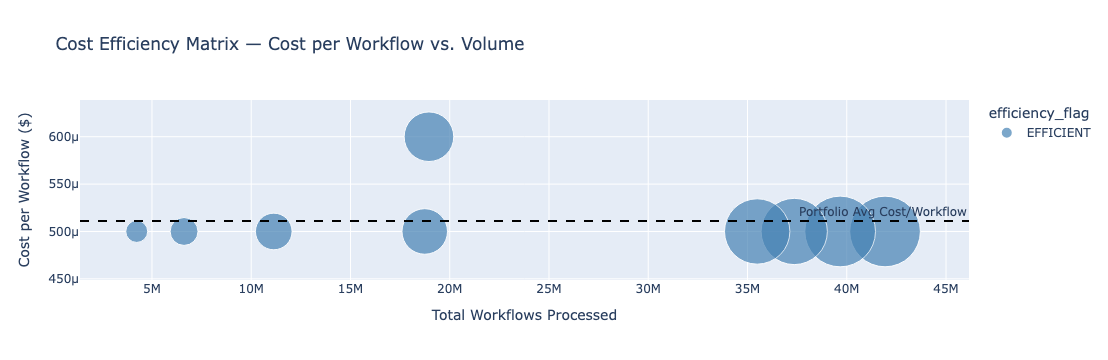

In [91]:
fig = px.scatter(
    df_efficiency,
    x="total_workflows", y="cost_per_workflow",
    size="total_cost",
    color="efficiency_flag",
    hover_name="product_name",
    hover_data=["sla_tier", "revenue_per_workflow", "pct_above_avg"],
    size_max=50,
    title="Cost Efficiency Matrix — Cost per Workflow vs. Volume",
    labels={
        "total_workflows": "Total Workflows Processed",
        "cost_per_workflow": "Cost per Workflow ($)"
    },
    color_discrete_map={
        "HIGH INEFFICIENCY": "red",
        "MODERATE INEFFICIENCY": "orange",
        "EFFICIENT": "steelblue"
    }
)
fig.add_hline(
    y=df_efficiency["portfolio_avg_cpw"].iloc[0],
    line_dash="dash", line_color="black",
    annotation_text="Portfolio Avg Cost/Workflow"
)
fig.show()

In [92]:
# %% [markdown]
# ## Waste Summary — Total Estimated Waste ($)
# Rolls up all waste signals into a single estimated waste figure.

# %%
sql = """
WITH nonprod_waste AS (
    SELECT
        'Non-Prod Overrun' AS waste_category,
        ROUND(SUM(CASE
            WHEN environment != 'prod'
             AND cost_usd > 0
            THEN cost_usd * 0.40  -- assume 40% of non-prod is recoverable
            ELSE 0
        END), 2) AS estimated_waste_usd
    FROM billing_case01_enriched
),
forecast_waste AS (
    SELECT
        'Over-Provisioned Capacity' AS waste_category,
        ROUND(SUM(CASE
            WHEN forecast_baseline_cost > cost_usd
            THEN forecast_baseline_cost - cost_usd
            ELSE 0
        END), 2) AS estimated_waste_usd
    FROM billing_case01_enriched
),
dark_spend_waste AS (
    SELECT
        'Unattributed Dark Spend' AS waste_category,
        ROUND(SUM(CASE
            WHEN allocation_status = 'unallocated'
            THEN cost_usd
            ELSE 0
        END), 2) AS estimated_waste_usd
    FROM billing_case01_enriched
)
SELECT * FROM nonprod_waste
UNION ALL
SELECT * FROM forecast_waste
UNION ALL
SELECT * FROM dark_spend_waste
"""
df_waste_summary = pd.read_sql(sql, conn)
df_waste_summary["pct_of_total"] = round(
    df_waste_summary["estimated_waste_usd"] /
    df_waste_summary["estimated_waste_usd"].sum() * 100, 1
)
df_waste_summary

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/4066223367.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_waste_summary = pd.read_sql(sql, conn)


,waste_category,estimated_waste_usd,pct_of_total
0,Non-Prod Overrun,1.628151e+04,0.0
1,Unattributed Dark Spend,1.245965e+04,0.0
2,Over-Provisioned Capacity,8.630724e+08,100.0


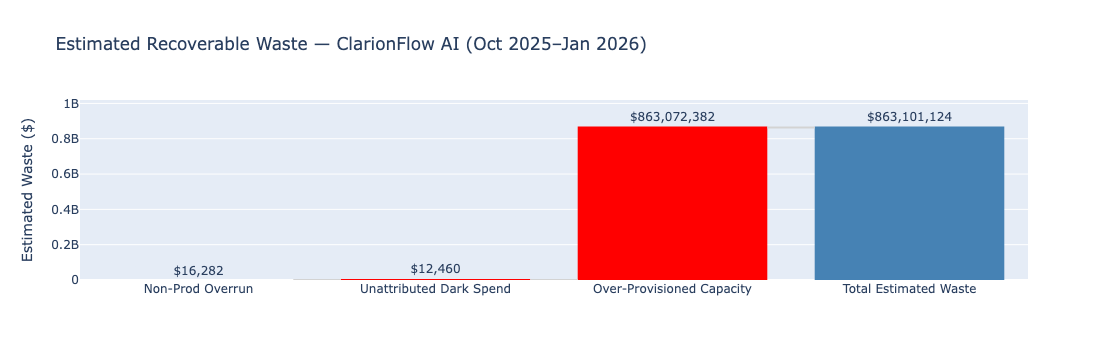

In [93]:
import plotly.graph_objects as go

fig = go.Figure()

# Waterfall chart — most impactful for a slide
fig = go.Figure(go.Waterfall(
    name="Waste Breakdown",
    orientation="v",
    measure=["relative", "relative", "relative", "total"],
    x=[*df_waste_summary["waste_category"].tolist(), "Total Estimated Waste"],
    y=[*df_waste_summary["estimated_waste_usd"].tolist(),
       df_waste_summary["estimated_waste_usd"].sum()],
    text=[f"${v:,.0f}" for v in df_waste_summary["estimated_waste_usd"].tolist()] +
         [f"${df_waste_summary['estimated_waste_usd'].sum():,.0f}"],
    textposition="outside",
    connector={"line": {"color": "lightgray"}},
    increasing={"marker": {"color": "red"}},
    totals={"marker": {"color": "steelblue"}}
))
fig.update_layout(
    title="Estimated Recoverable Waste — ClarionFlow AI (Oct 2025–Jan 2026)",
    yaxis_title="Estimated Waste ($)",
    showlegend=False
)
fig.show()

In [94]:
# %% [markdown]
# ## Waste Sanity Check — What are the actual total figures?

# %%
sql = """
SELECT
    ROUND(SUM(cost_usd), 2)               AS total_actual_spend,
    ROUND(SUM(forecast_baseline_cost), 2) AS total_forecast,
    ROUND(SUM(budget_amount), 2)          AS total_budget,
    ROUND(SUM(forecast_baseline_cost) - SUM(cost_usd), 2) AS raw_forecast_gap,
    COUNT(*) AS total_rows
FROM billing_case01_enriched
"""
df_sanity = pd.read_sql(sql, conn)
df_sanity

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/1941691846.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sanity = pd.read_sql(sql, conn)


,total_actual_spend,total_forecast,total_budget,raw_forecast_gap,total_rows
0,110020.4,8.631824e+08,8.617565e+08,8.630724e+08,5000


In [95]:
# %% [markdown]
# ## Waste Summary — Realistic Recoverable Waste (Capped Logic)
# Caps over-provisioning waste per row to avoid synthetic data inflation.
# Applies conservative recovery assumptions based on FinOps industry benchmarks.

# %%
sql = """
WITH waste_components AS (
    SELECT
        -- Non-prod overrun: dev/staging spend exceeding 30% of prod equivalent
        -- Conservative: recover 30% of non-prod spend
        ROUND(SUM(CASE
            WHEN environment IN ('dev', 'staging')
            THEN cost_usd * 0.30
            ELSE 0
        END), 2) AS nonprod_waste_usd,

        -- Over-provisioning: capped at 20% variance per row to avoid outlier inflation
        -- Only count rows where forecast exceeds actual by 10-50% (realistic range)
        ROUND(SUM(CASE
            WHEN forecast_baseline_cost > cost_usd
             AND (forecast_baseline_cost - cost_usd) / NULLIF(forecast_baseline_cost, 0)
                 BETWEEN 0.10 AND 0.50
            THEN (forecast_baseline_cost - cost_usd) * 0.50
            ELSE 0
        END), 2) AS overprovision_waste_usd,

        -- Dark spend: unallocated spend that could be eliminated if governed
        -- Conservative: recover 25% (not all dark spend is waste, some is just untagged)
        ROUND(SUM(CASE
            WHEN allocation_status = 'unallocated'
            THEN cost_usd * 0.25
            ELSE 0
        END), 2) AS dark_spend_waste_usd,

        ROUND(SUM(cost_usd), 2) AS total_actual_spend

    FROM billing_case01_enriched
)
SELECT
    nonprod_waste_usd,
    overprovision_waste_usd,
    dark_spend_waste_usd,
    nonprod_waste_usd + overprovision_waste_usd + dark_spend_waste_usd AS total_waste_usd,
    total_actual_spend,
    ROUND(
        (nonprod_waste_usd + overprovision_waste_usd + dark_spend_waste_usd)
        * 100.0 / NULLIF(total_actual_spend, 0), 1
    ) AS waste_as_pct_of_spend
FROM waste_components
"""
df_waste_fixed = pd.read_sql(sql, conn)
df_waste_fixed

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_55432/108991078.py:52: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_waste_fixed = pd.read_sql(sql, conn)


,nonprod_waste_usd,overprovision_waste_usd,dark_spend_waste_usd,total_waste_usd,total_actual_spend,waste_as_pct_of_spend
0,12211.13,0.0,3114.91,15326.04,110020.4,13.9


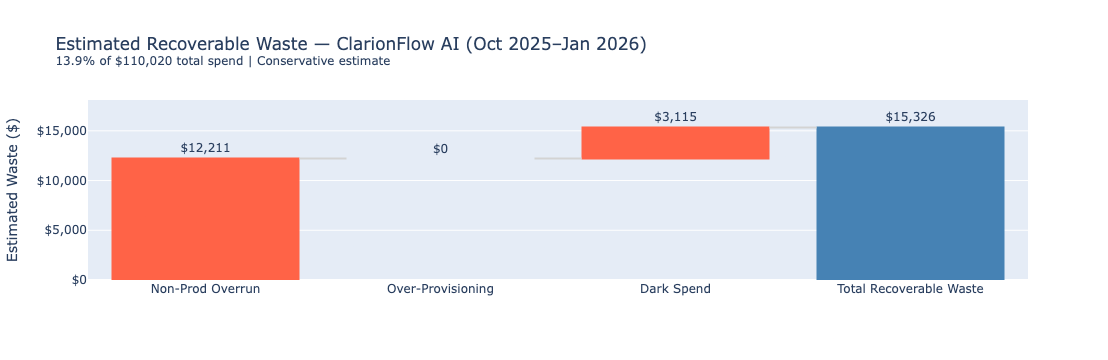

In [96]:
# Clean waterfall with realistic numbers
labels = ["Non-Prod Overrun", "Over-Provisioning", "Dark Spend", "Total Recoverable Waste"]
values = [
    df_waste_fixed["nonprod_waste_usd"].iloc[0],
    df_waste_fixed["overprovision_waste_usd"].iloc[0],
    df_waste_fixed["dark_spend_waste_usd"].iloc[0],
    df_waste_fixed["total_waste_usd"].iloc[0]
]
measures = ["relative", "relative", "relative", "total"]

fig = go.Figure(go.Waterfall(
    name="Waste",
    orientation="v",
    measure=measures,
    x=labels,
    y=values,
    text=[f"${v:,.0f}" for v in values],
    textposition="outside",
    connector={"line": {"color": "lightgray"}},
    increasing={"marker": {"color": "tomato"}},
    totals={"marker": {"color": "steelblue"}}
))

total_spend = df_waste_fixed["total_actual_spend"].iloc[0]
waste_pct = df_waste_fixed["waste_as_pct_of_spend"].iloc[0]

fig.update_layout(
    title=f"Estimated Recoverable Waste — ClarionFlow AI (Oct 2025–Jan 2026)<br>"
          f"<sup>{waste_pct}% of ${total_spend:,.0f} total spend | Conservative estimate</sup>",
    yaxis_title="Estimated Waste ($)",
    showlegend=False,
    yaxis_tickformat="$,.0f"
)
fig.show()